In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import random

In [2]:
os.chdir("..")

In [3]:
sales_df = pd.read_parquet('data/sales_data.parquet')
sales_df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,store_type,cluster,...,rolling_std_7,store_family_velocity,target_enc_store_family,oil_trend_30,promo_ratio_vs_avg,promo_during_payday,family_store_nb,family_state,family_onpromotion,is_family_unactive
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,...,NaN,NaN,0.000000,0.00,0.0,0,AUTOMOTIVE_1,AUTOMOTIVE_Pichincha,AUTOMOTIVE_0,0
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,...,NaN,0.000000,0.000000,0.00,0.0,0,AUTOMOTIVE_1,AUTOMOTIVE_Pichincha,AUTOMOTIVE_0,0
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,Quito,Pichincha,D,13,...,NaN,1.000000,1.000000,-0.17,0.0,0,AUTOMOTIVE_1,AUTOMOTIVE_Pichincha,AUTOMOTIVE_0,0
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,Quito,Pichincha,D,13,...,NaN,1.666667,1.666667,-0.02,0.0,0,AUTOMOTIVE_1,AUTOMOTIVE_Pichincha,AUTOMOTIVE_0,0
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,Quito,Pichincha,D,13,...,NaN,2.000000,2.000000,-0.02,0.0,0,AUTOMOTIVE_1,AUTOMOTIVE_Pichincha,AUTOMOTIVE_0,0


# 1. Families of products 

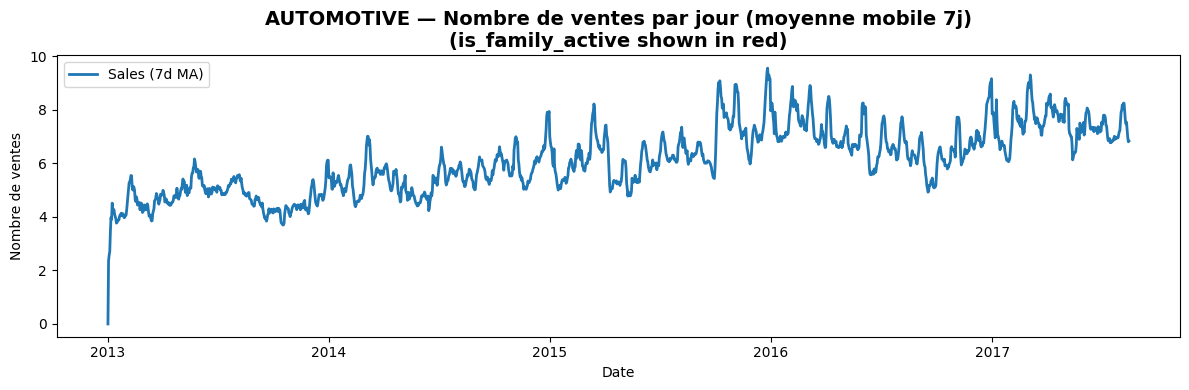

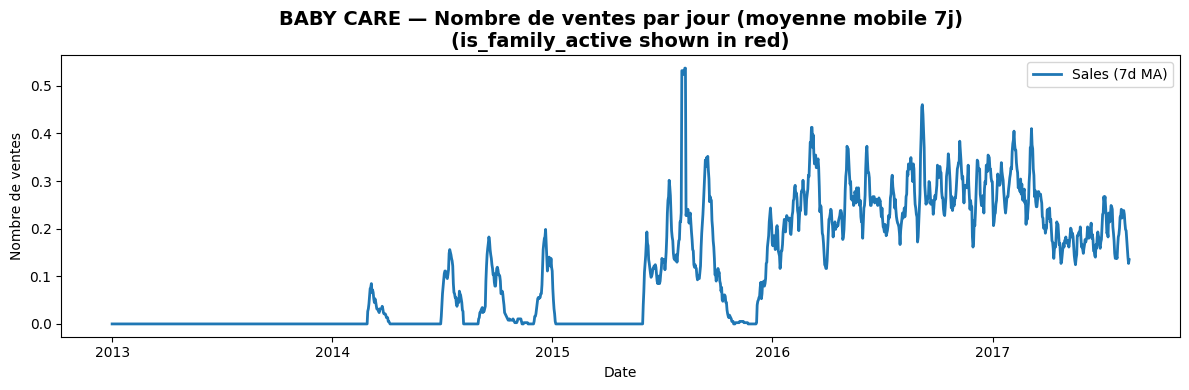

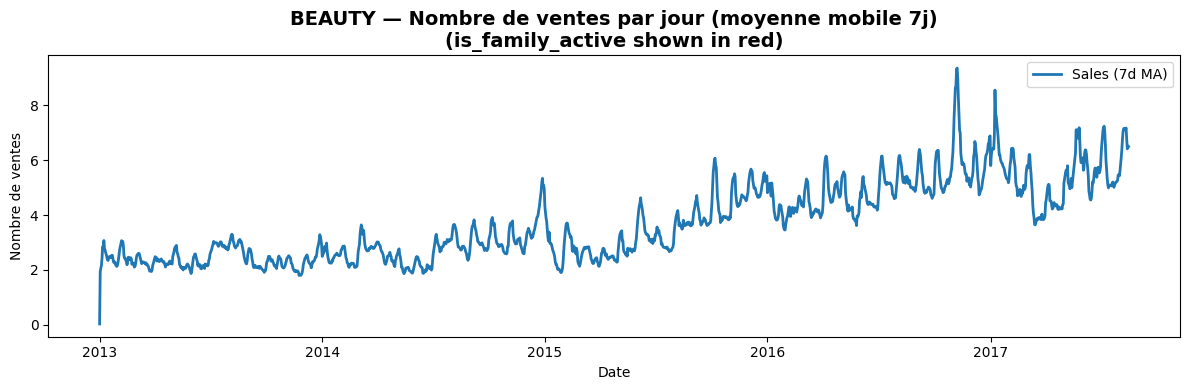

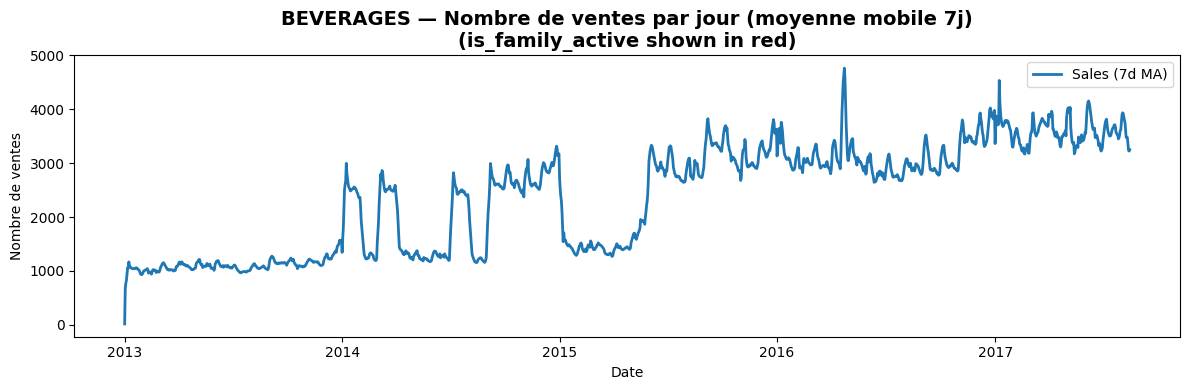

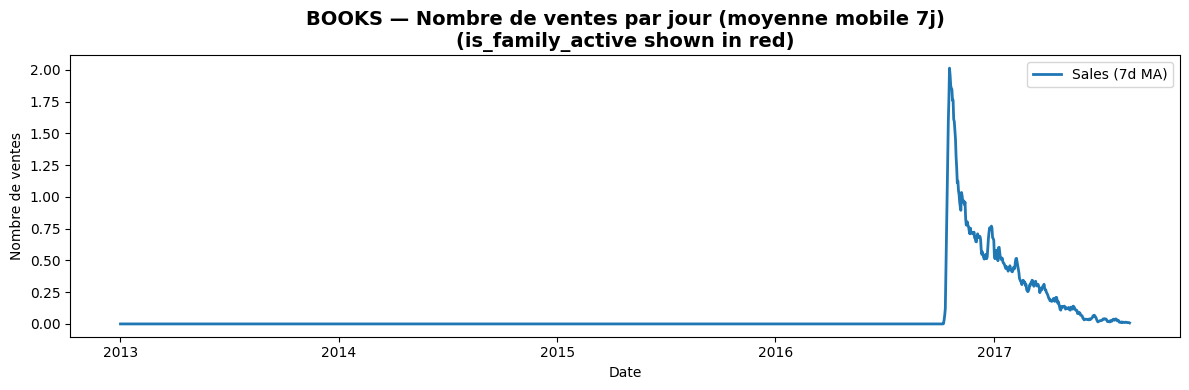

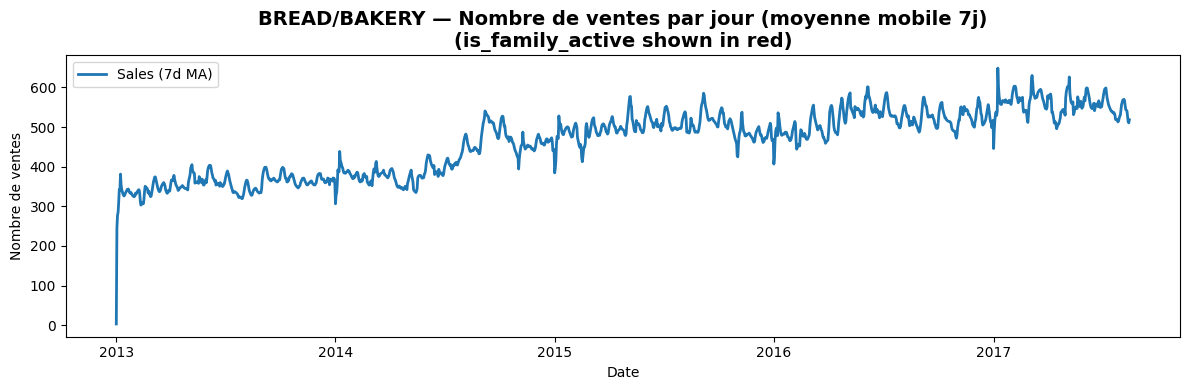

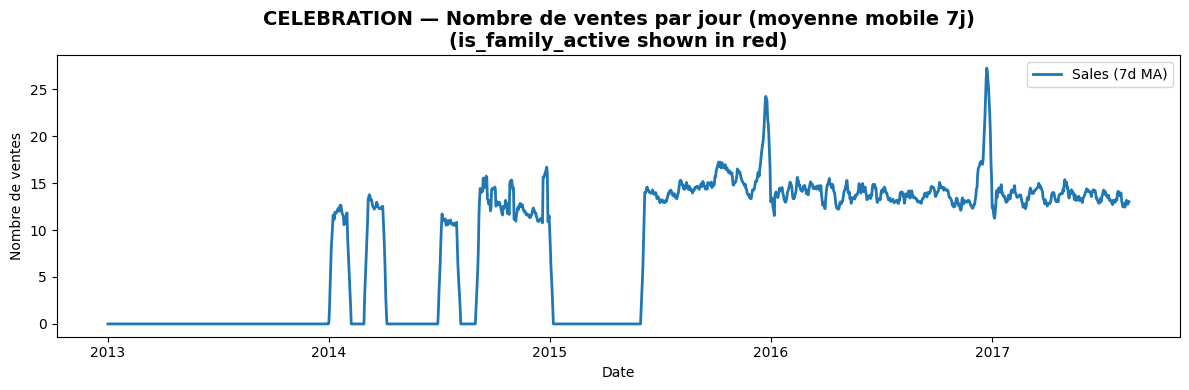

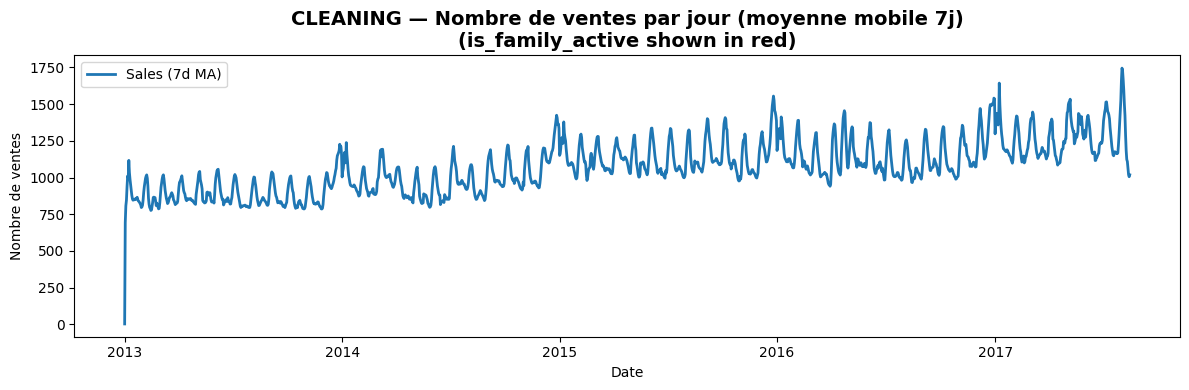

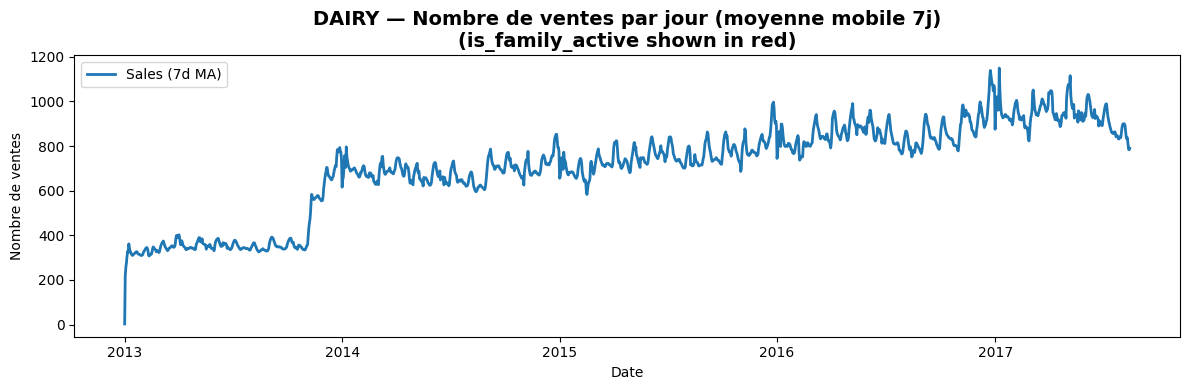

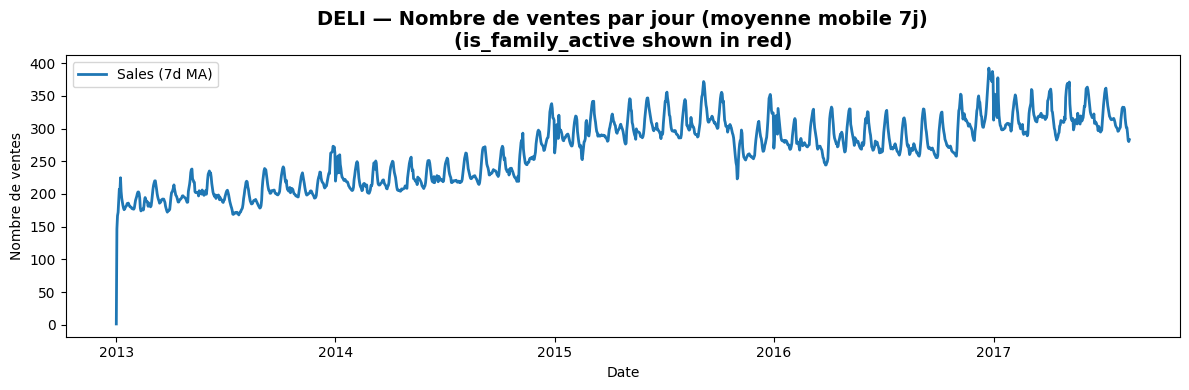

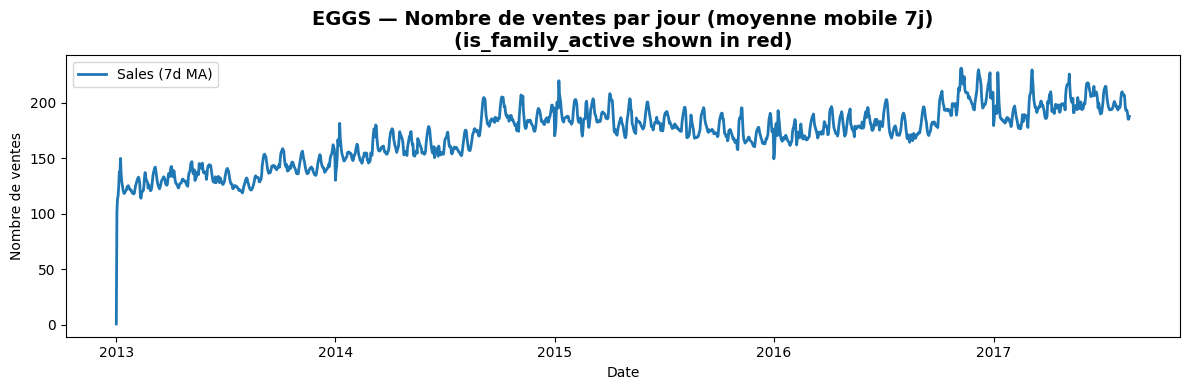

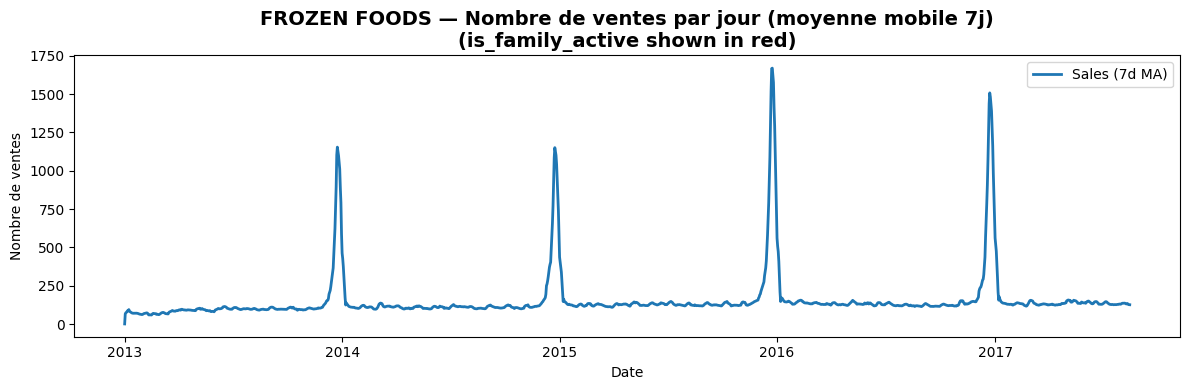

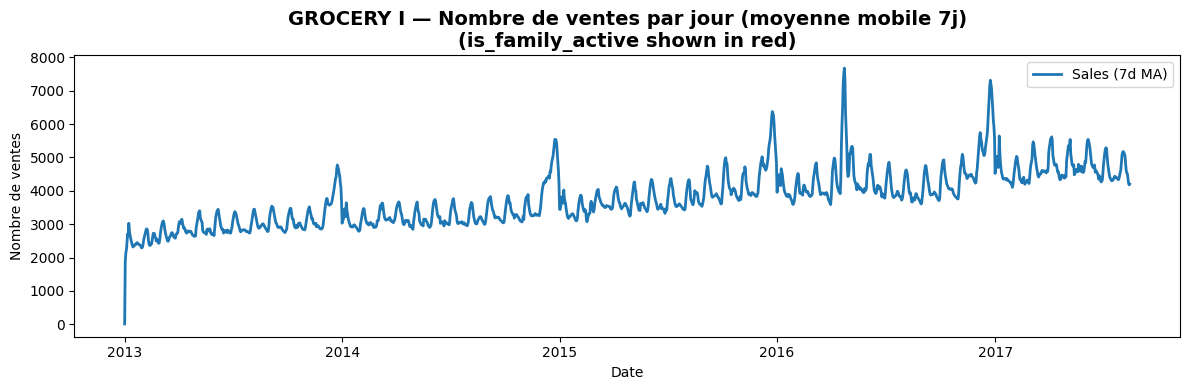

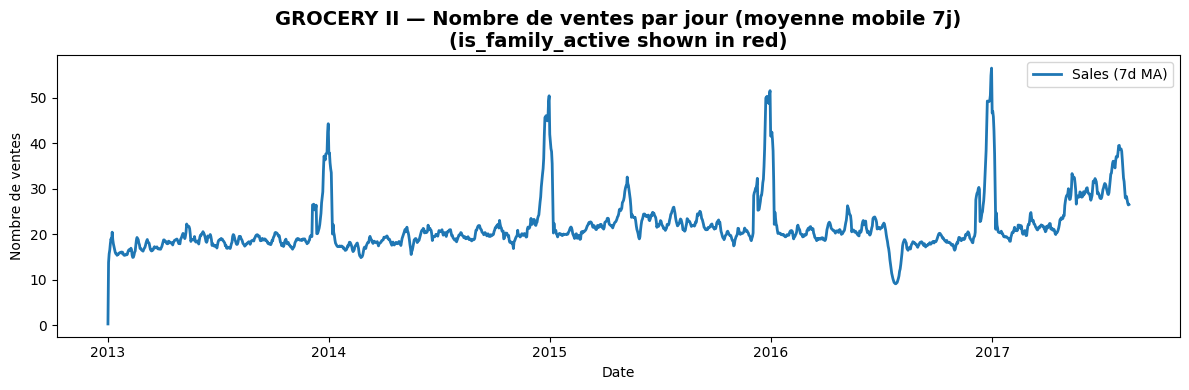

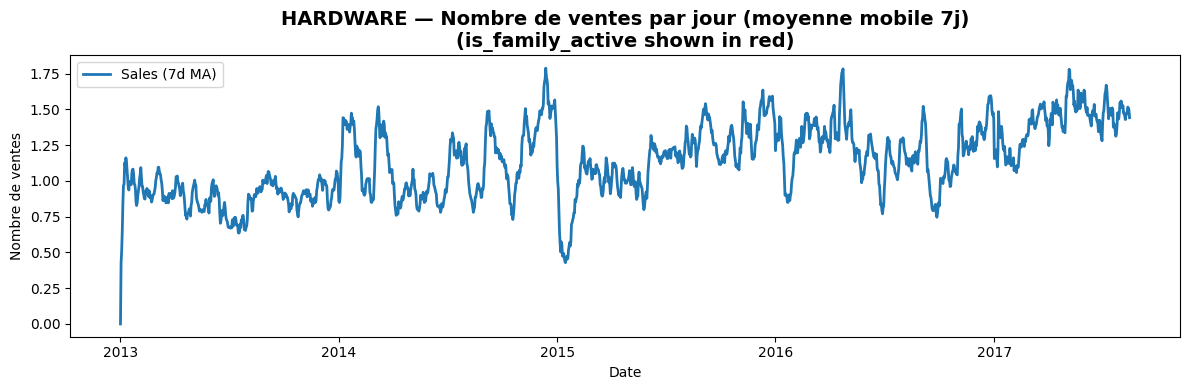

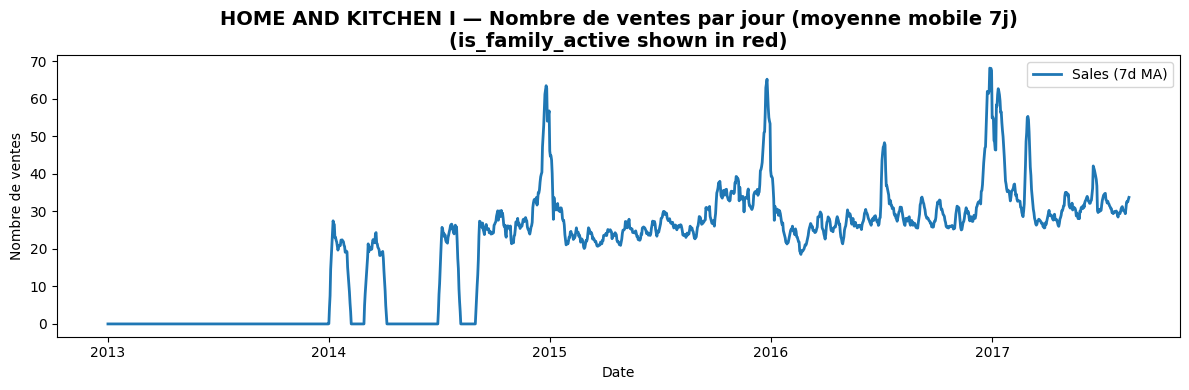

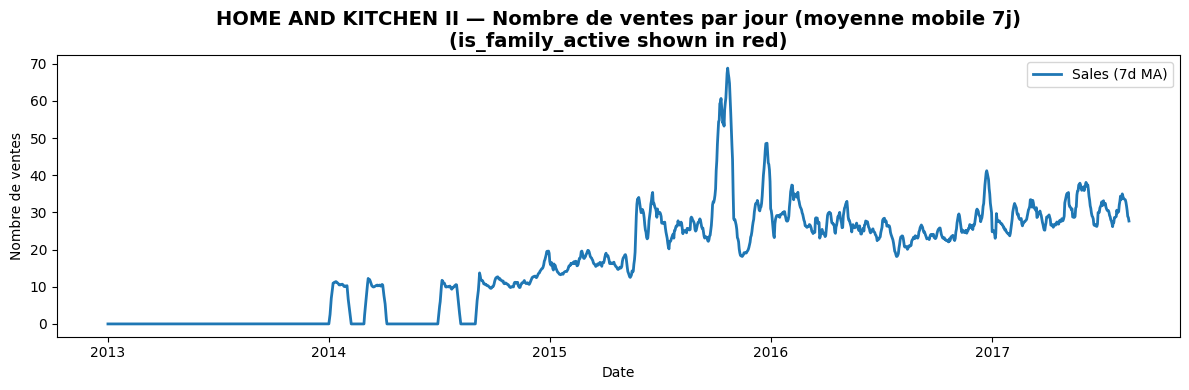

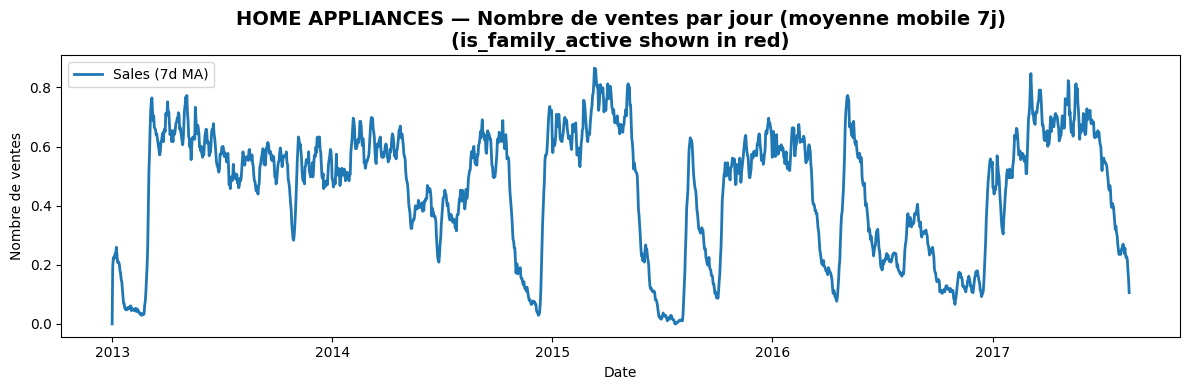

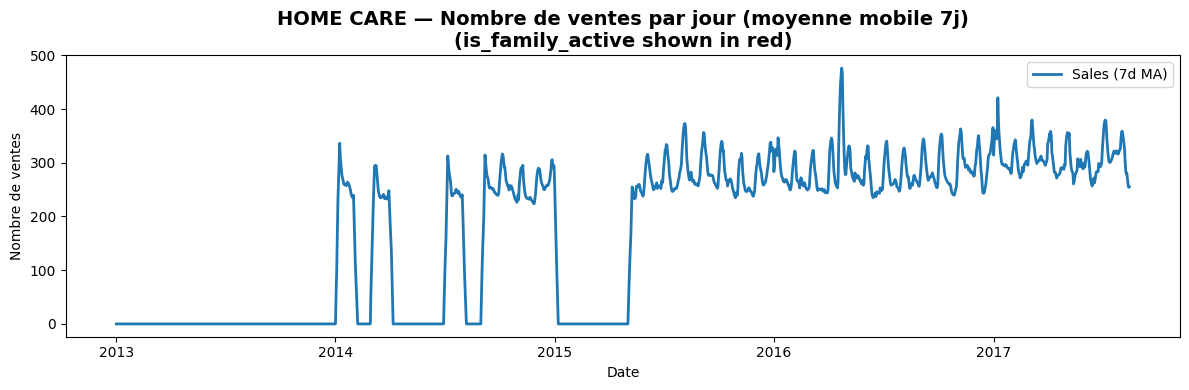

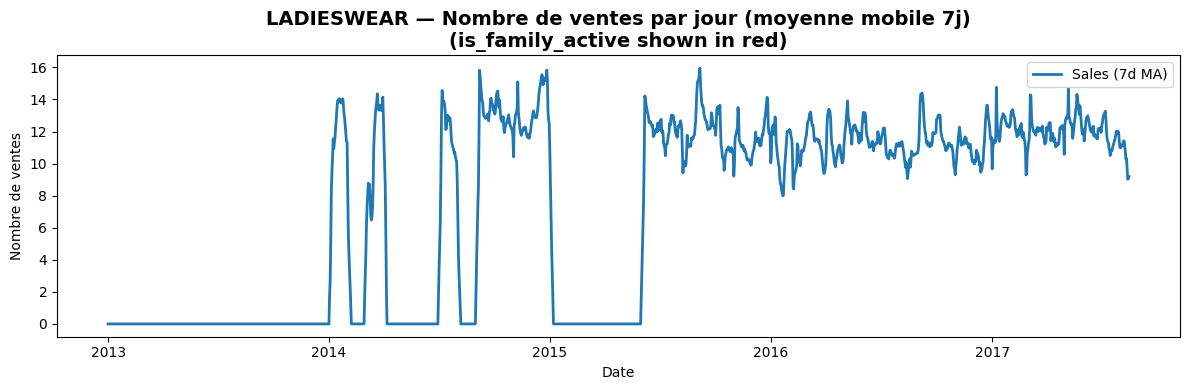

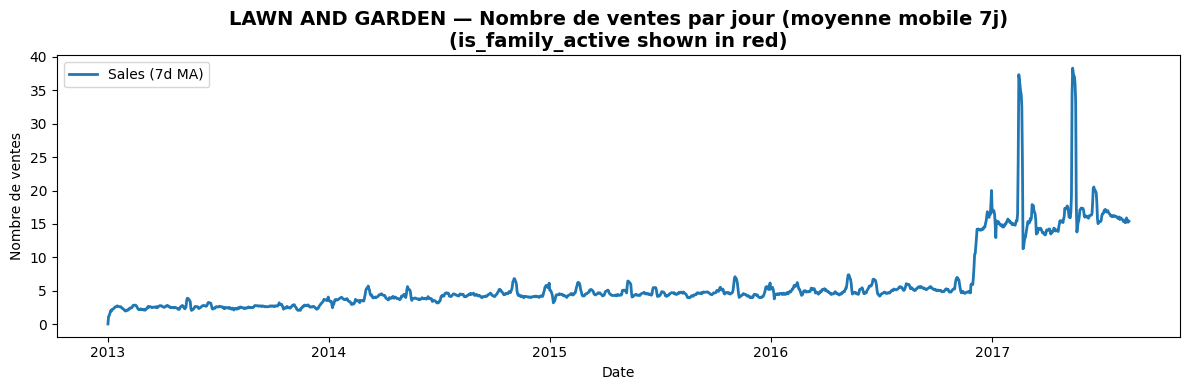

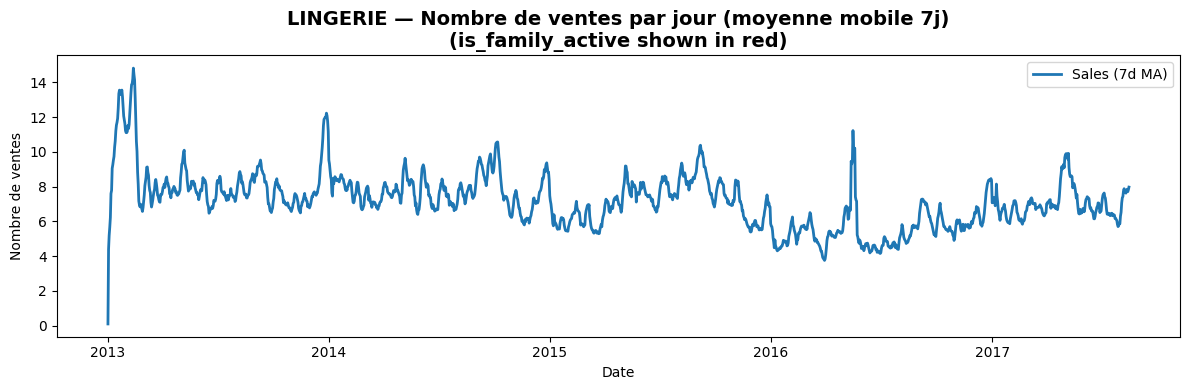

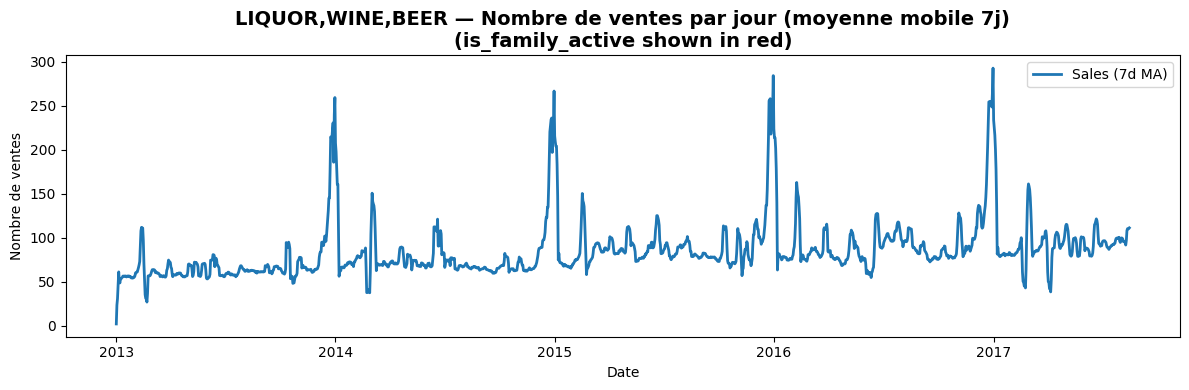

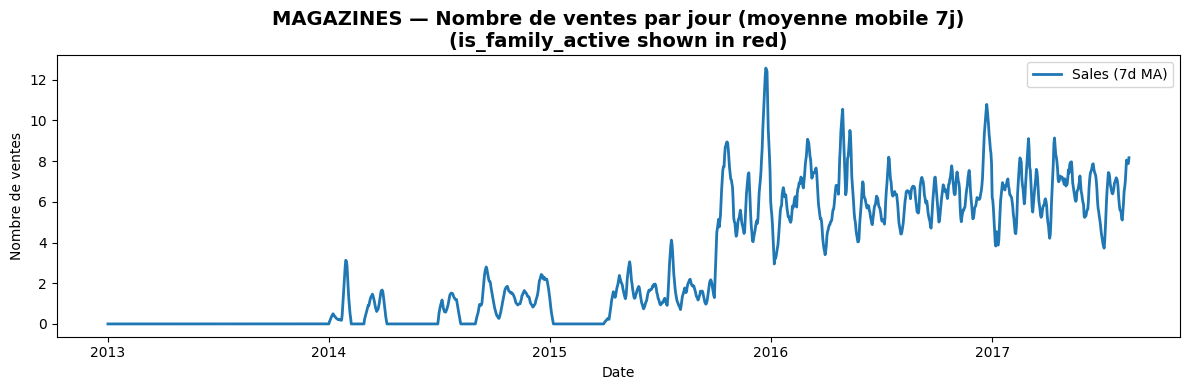

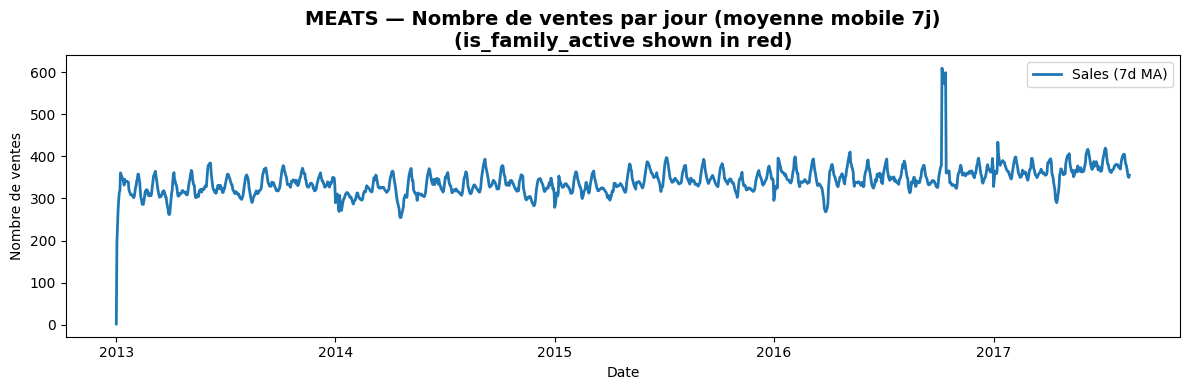

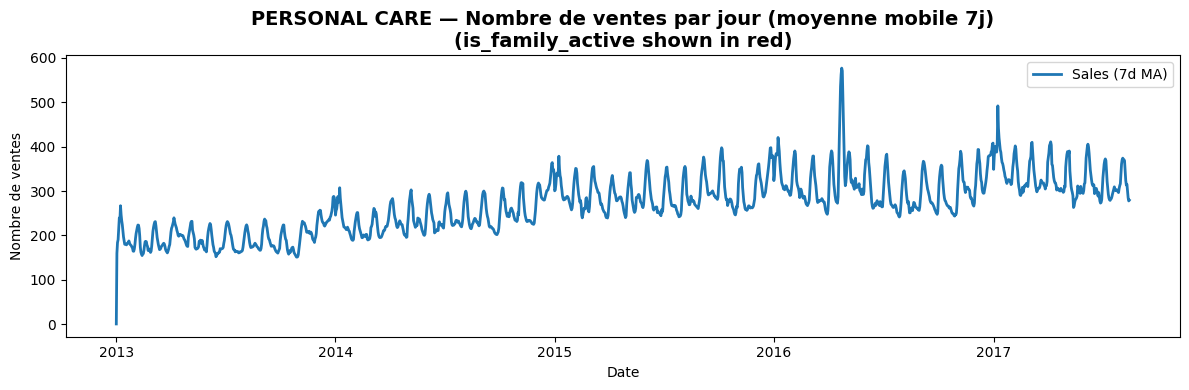

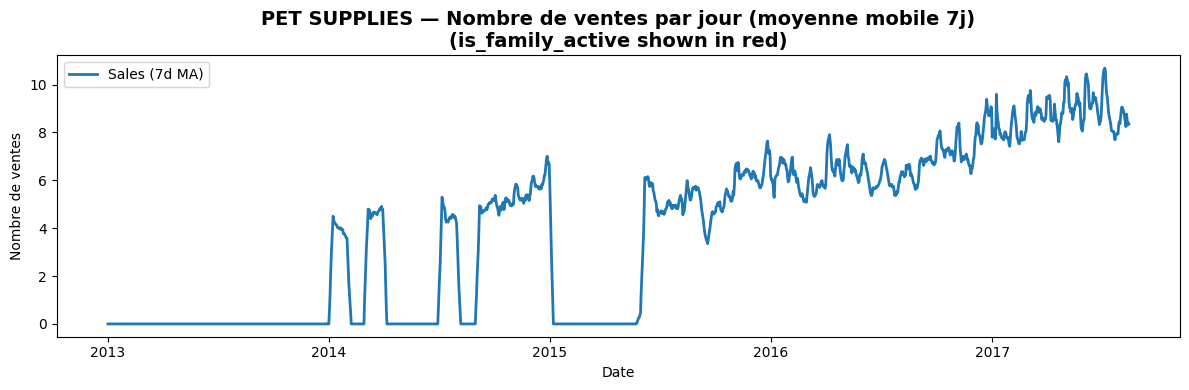

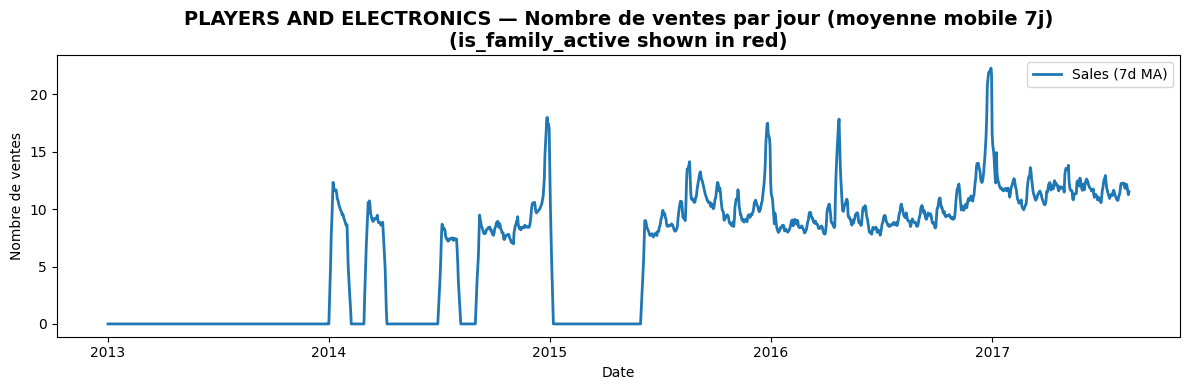

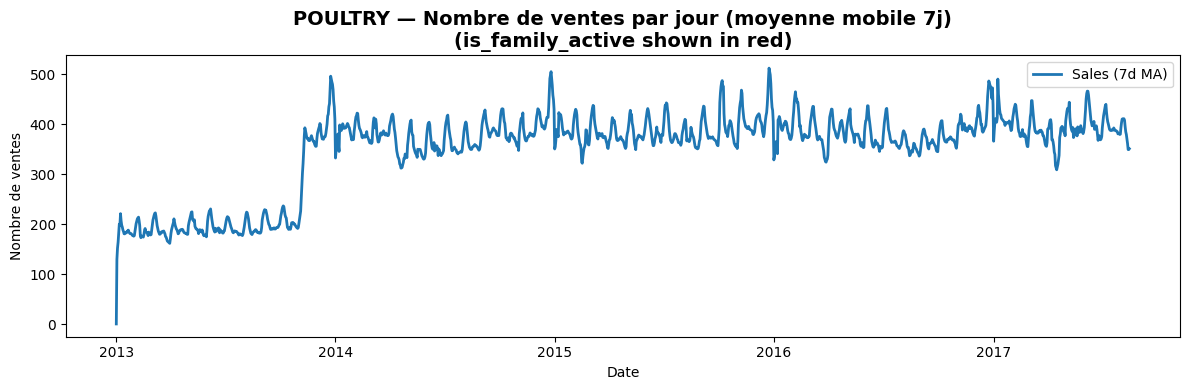

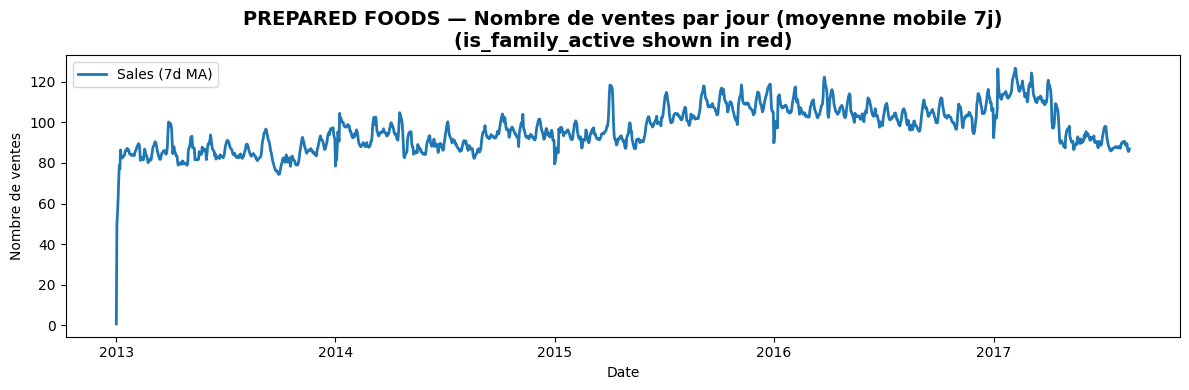

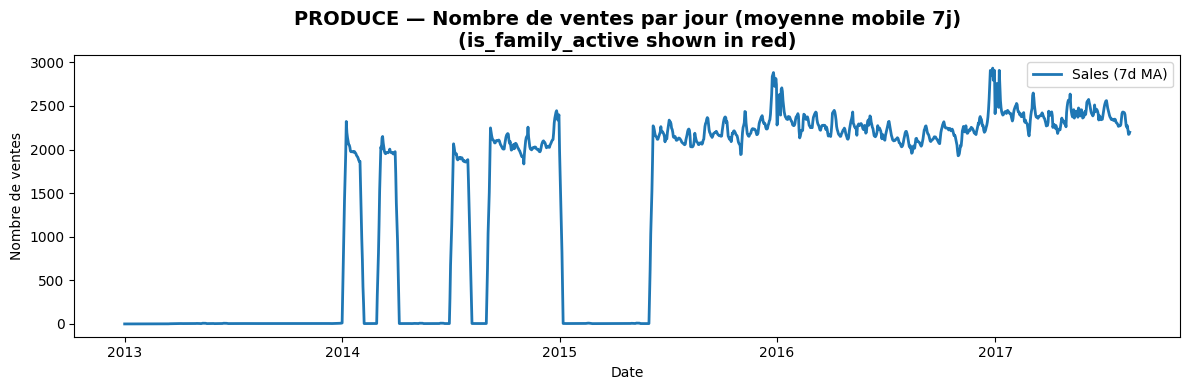

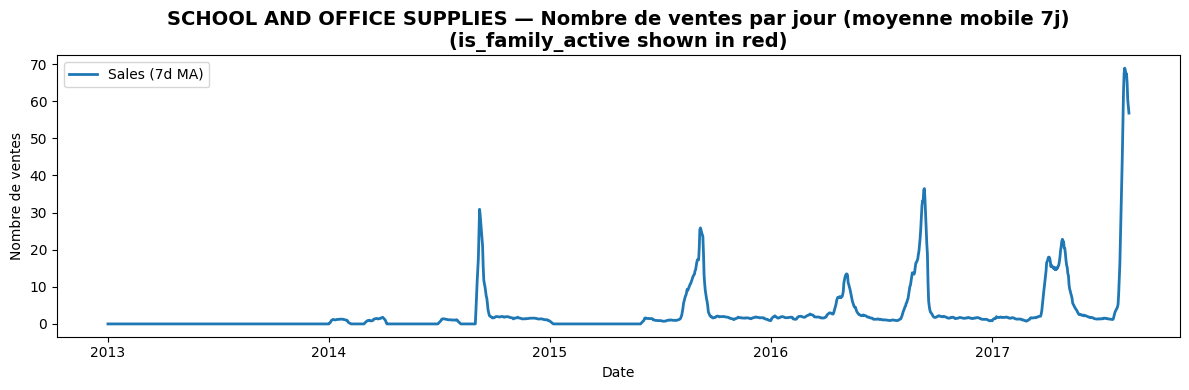

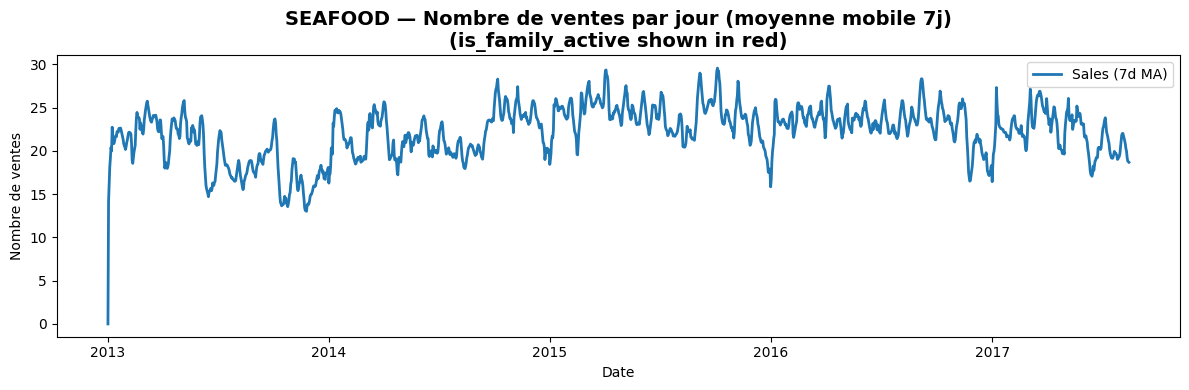

In [4]:
top_fams = sales_df['family'].value_counts().index.tolist()

for fam in top_fams:
    fam_df = sales_df[sales_df['family'] == fam]
    fam_daily_counts = fam_df.groupby('date')["sales"].mean()
    plt.figure(figsize=(12, 4))
    plt.plot(fam_daily_counts.index, fam_daily_counts.rolling(7, min_periods=1).mean(), label='Sales (7d MA)', linewidth=2)
    plt.title(f'{fam} — Nombre de ventes par jour (moyenne mobile 7j)\n(is_family_active shown in red)', fontsize=14, fontweight='bold')
    plt.ylabel('Nombre de ventes')
    plt.xlabel('Date')
    plt.legend()
    plt.tight_layout()
    plt.show()


Problème : on a des familles sans ventes sur de longues périodes. 

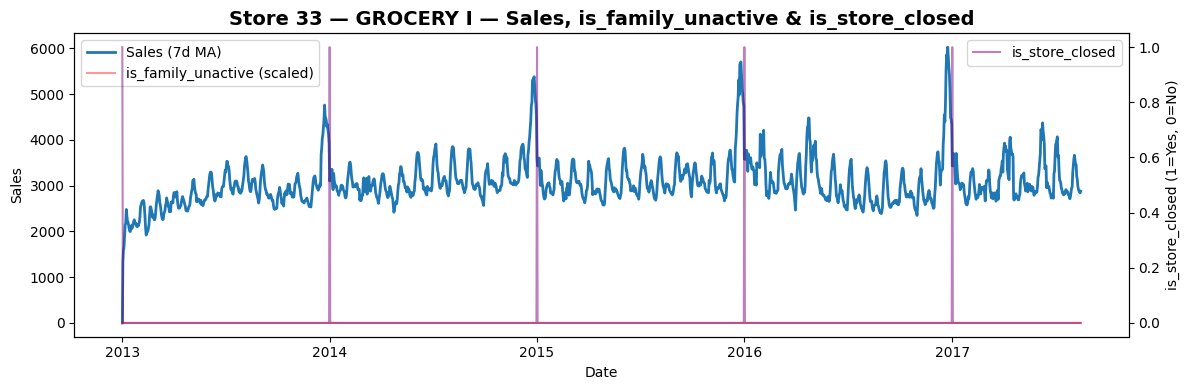

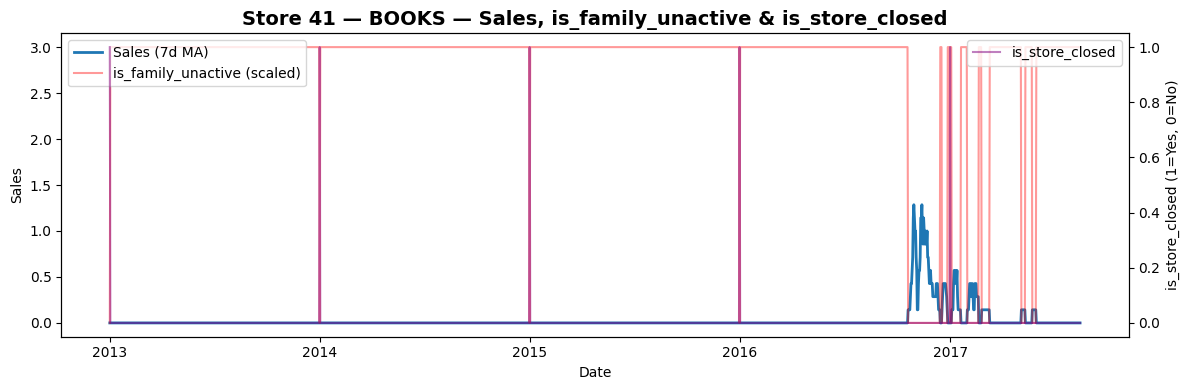

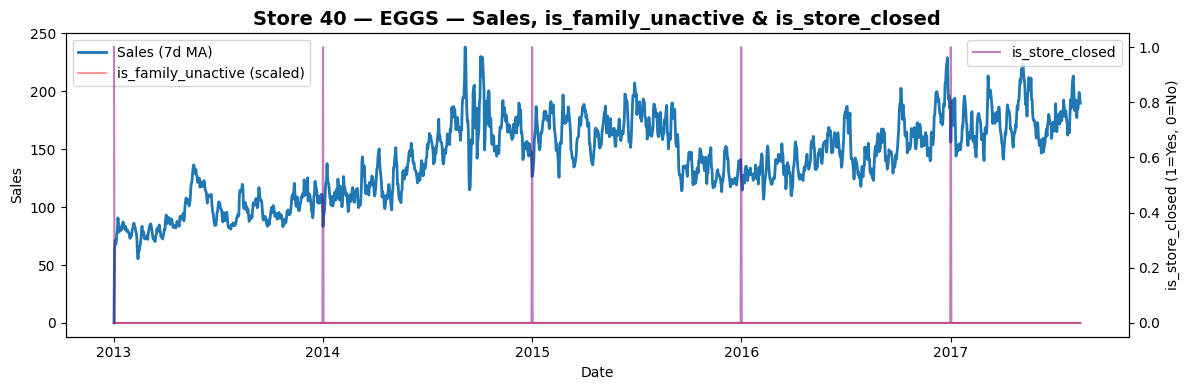

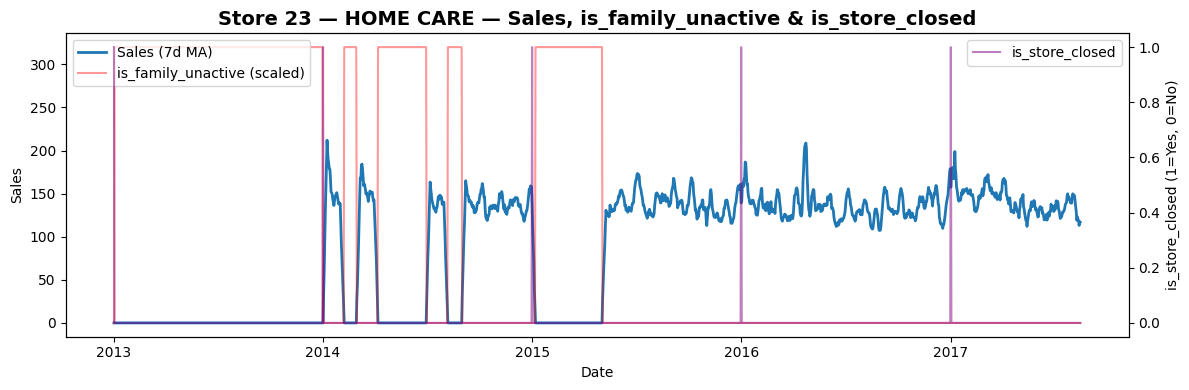

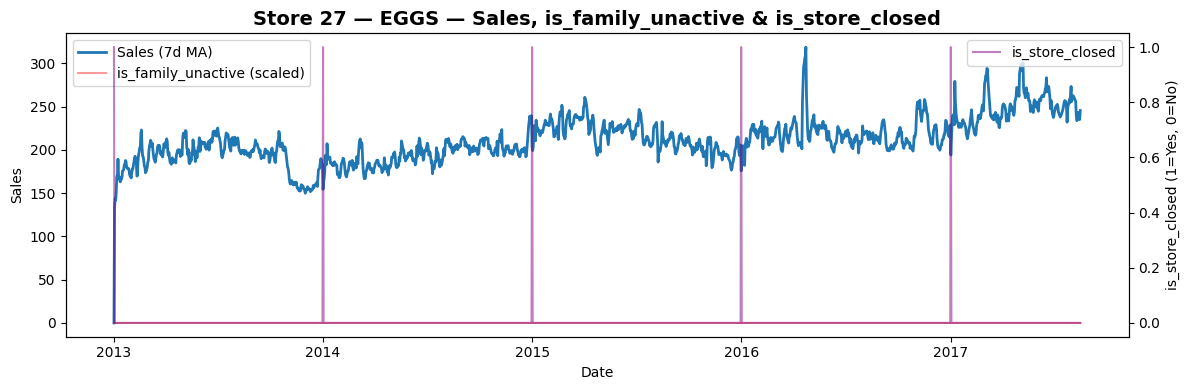

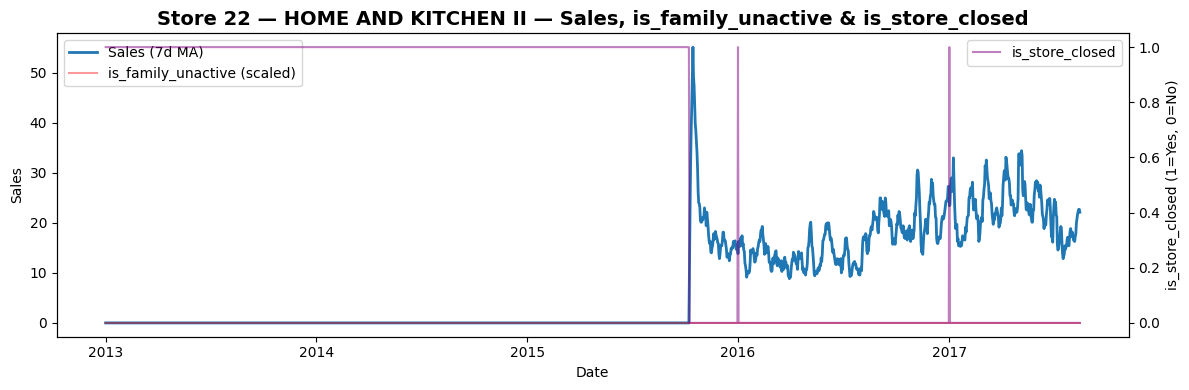

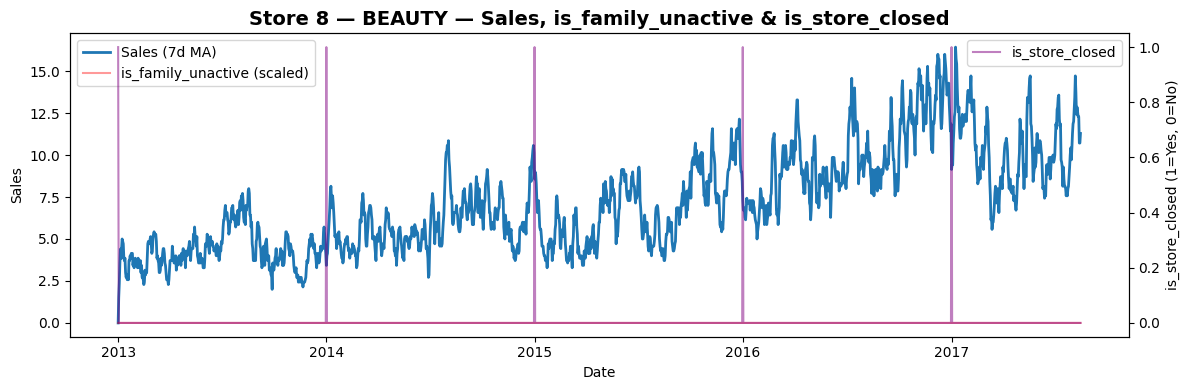

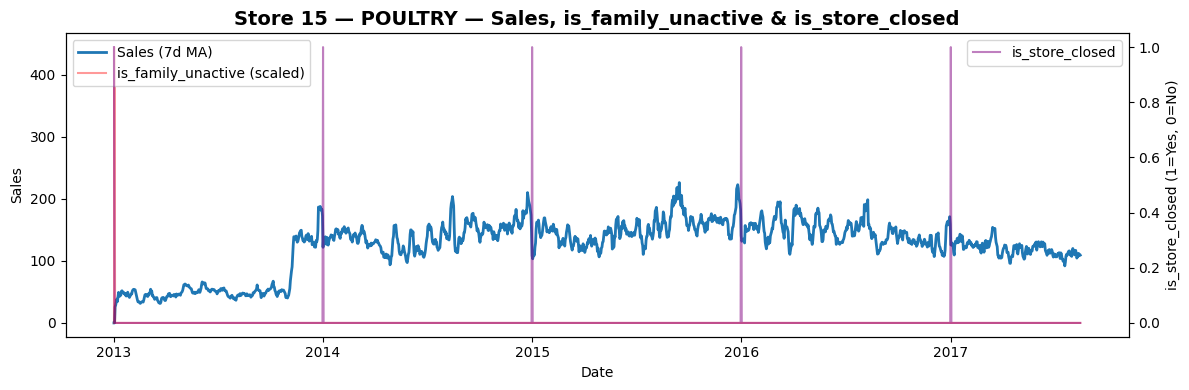

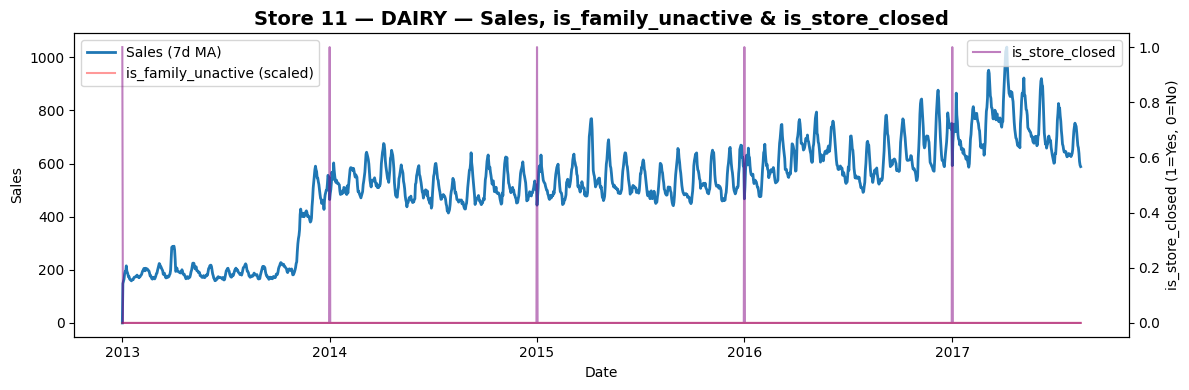

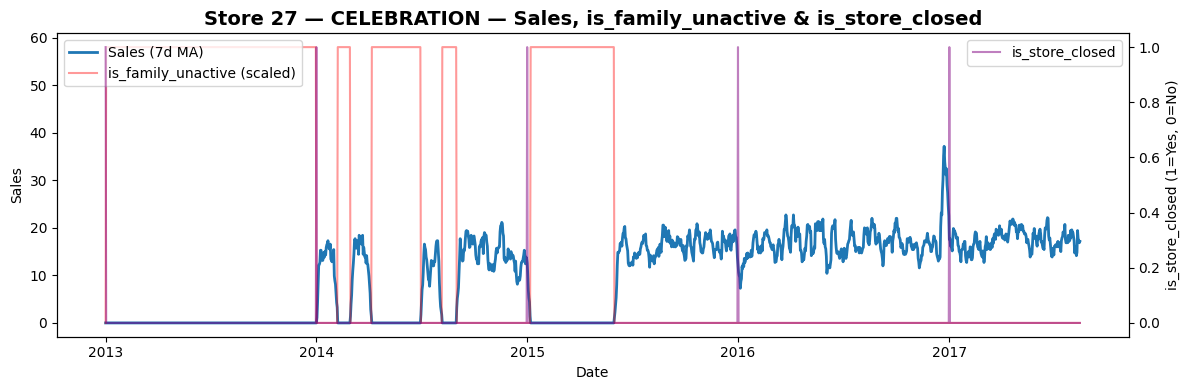

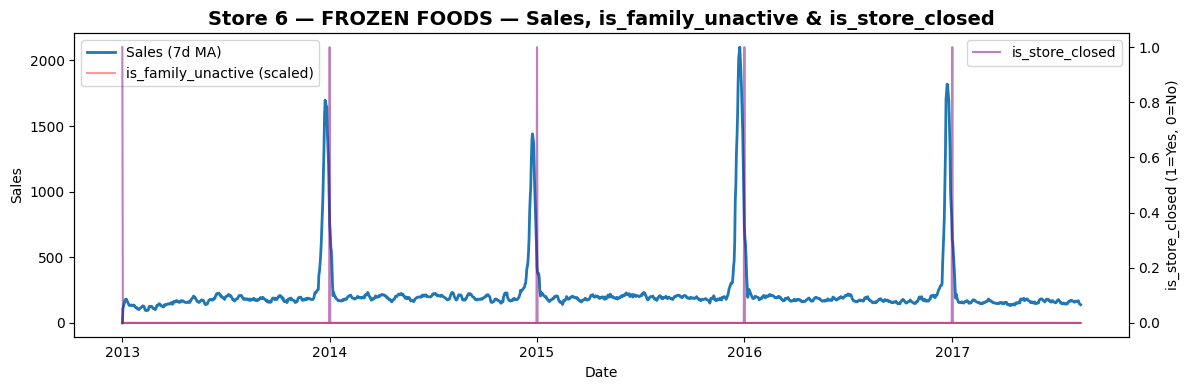

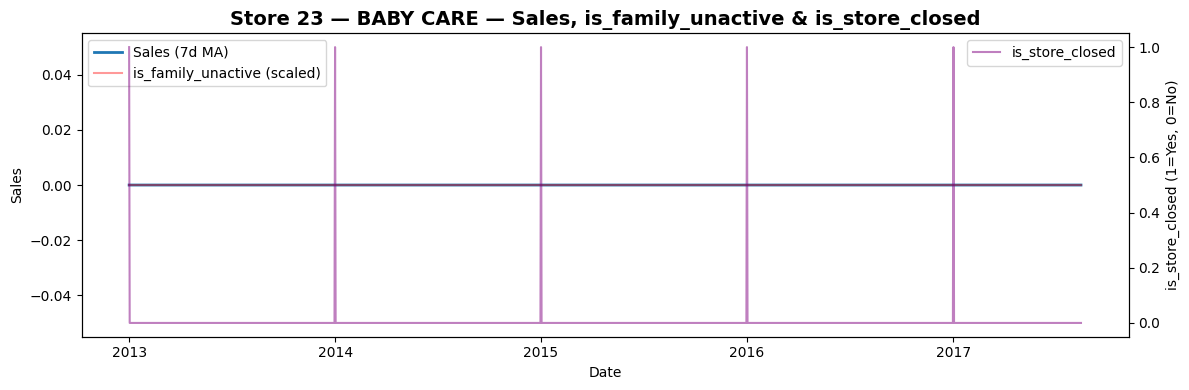

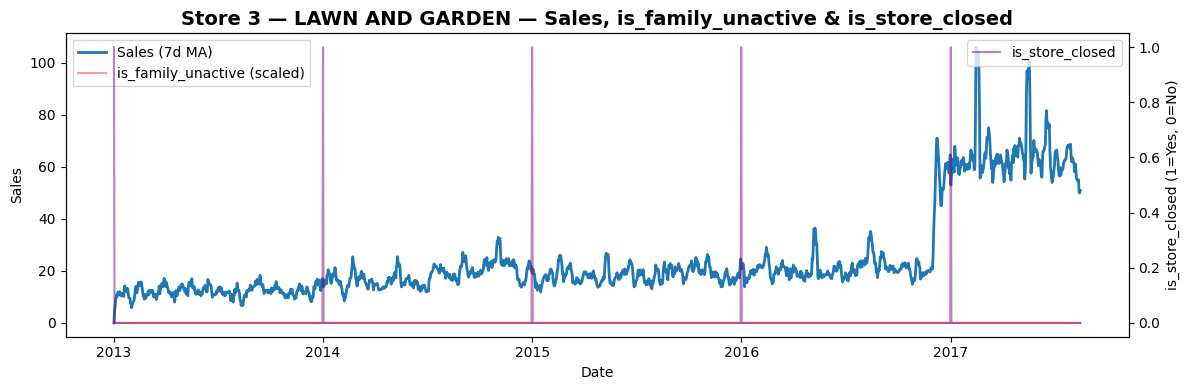

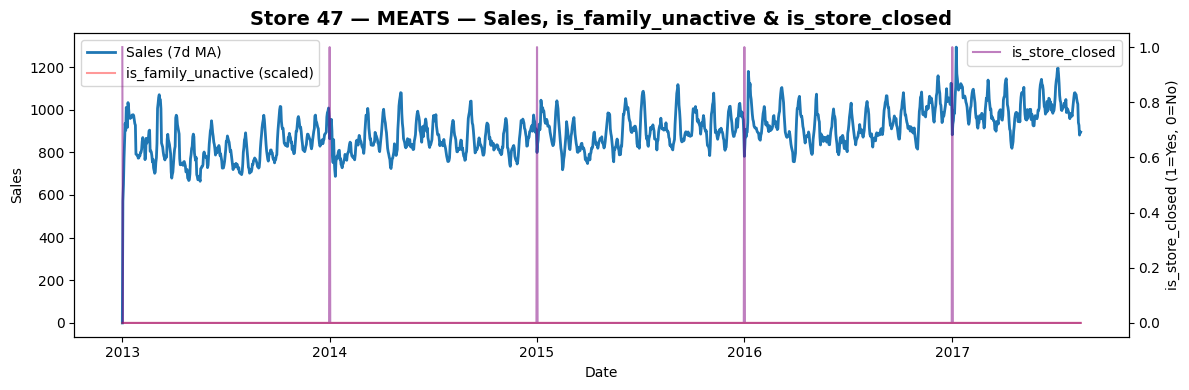

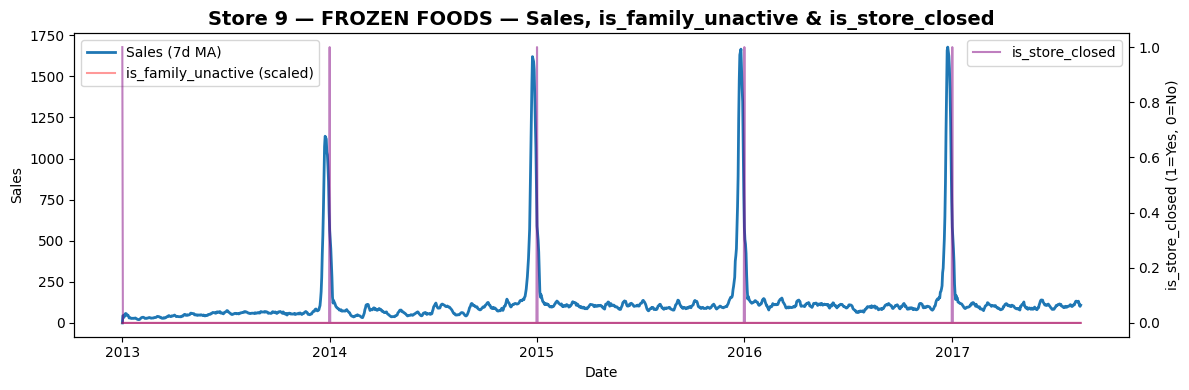

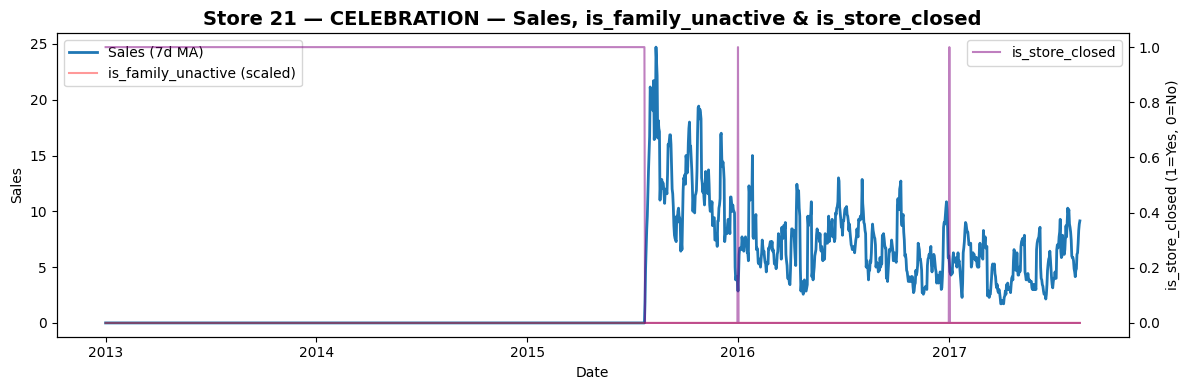

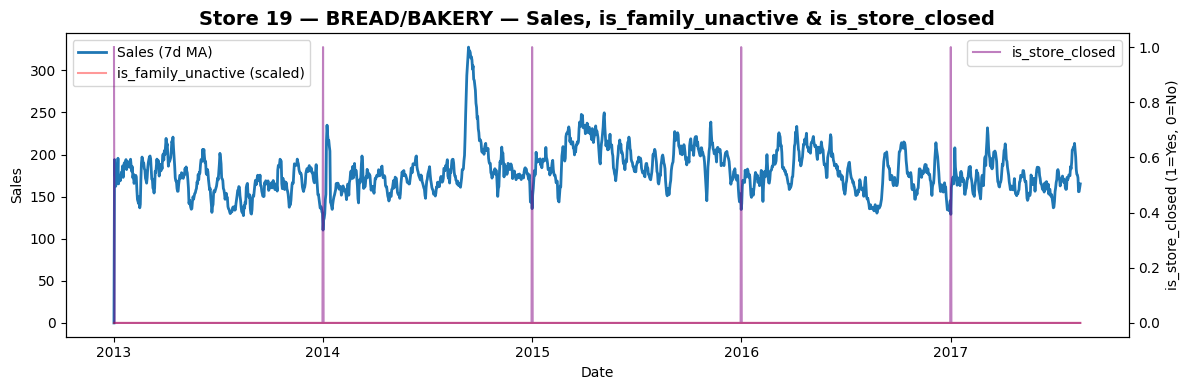

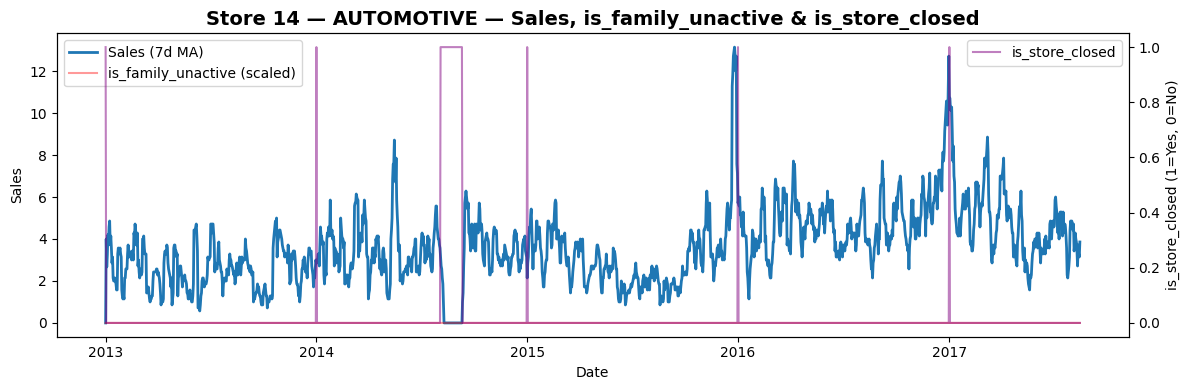

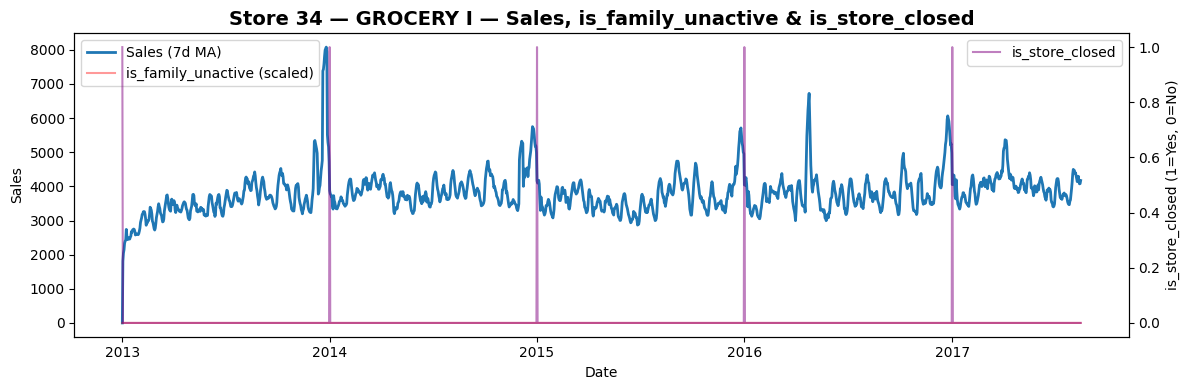

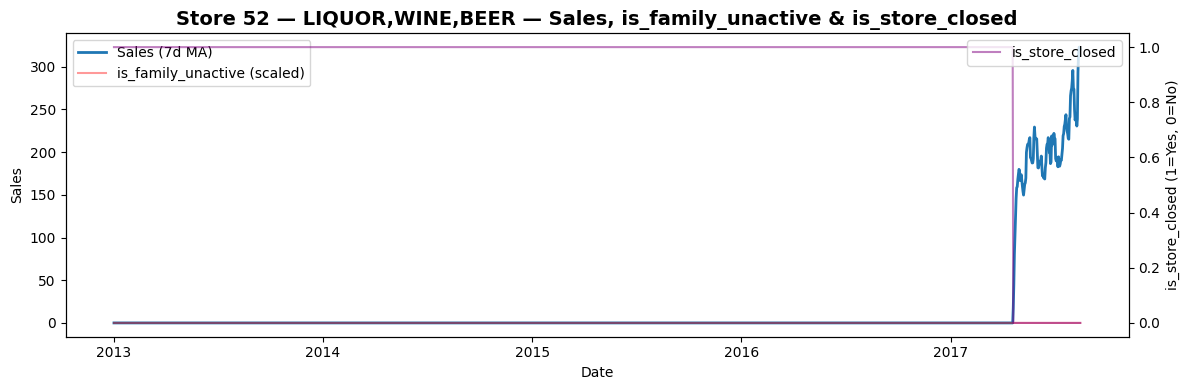

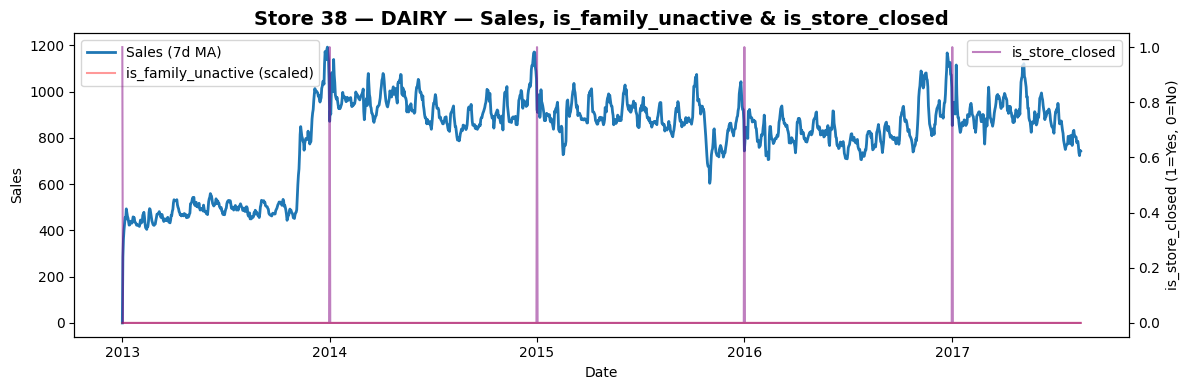

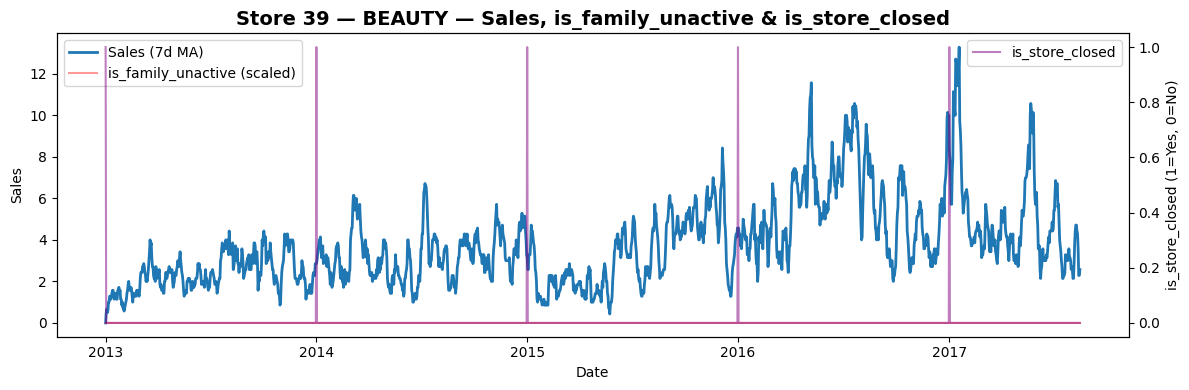

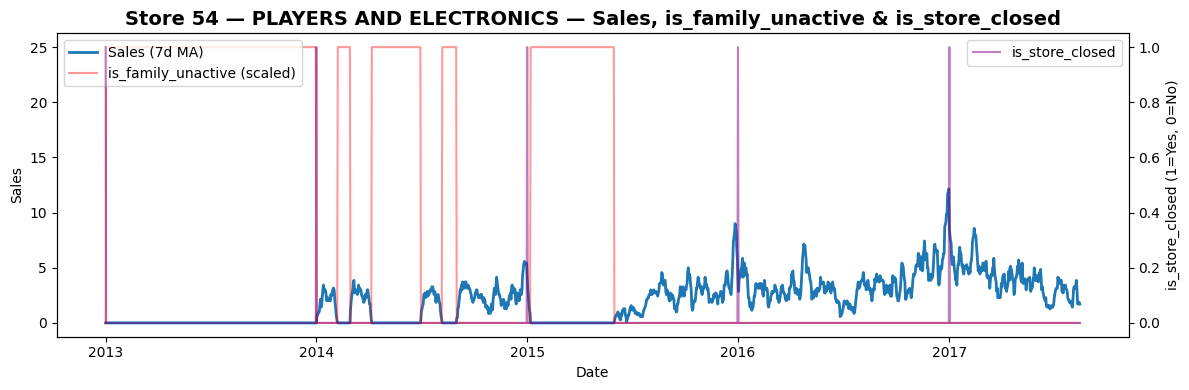

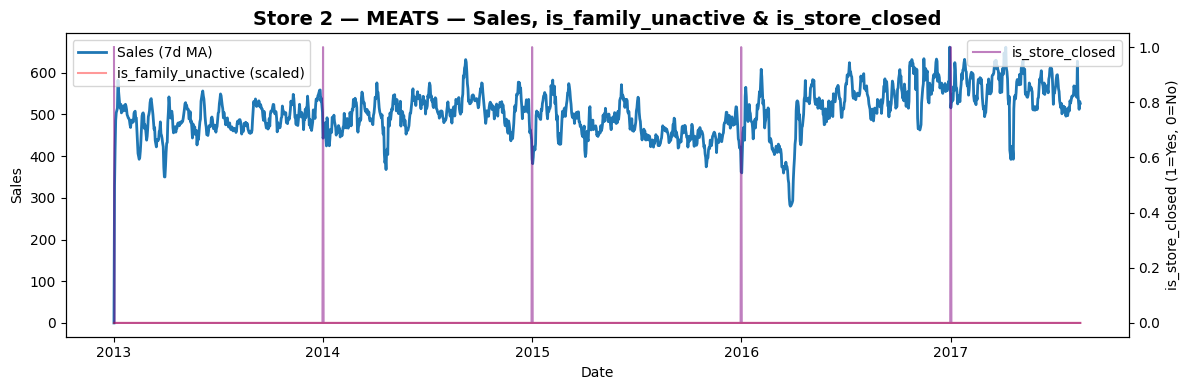

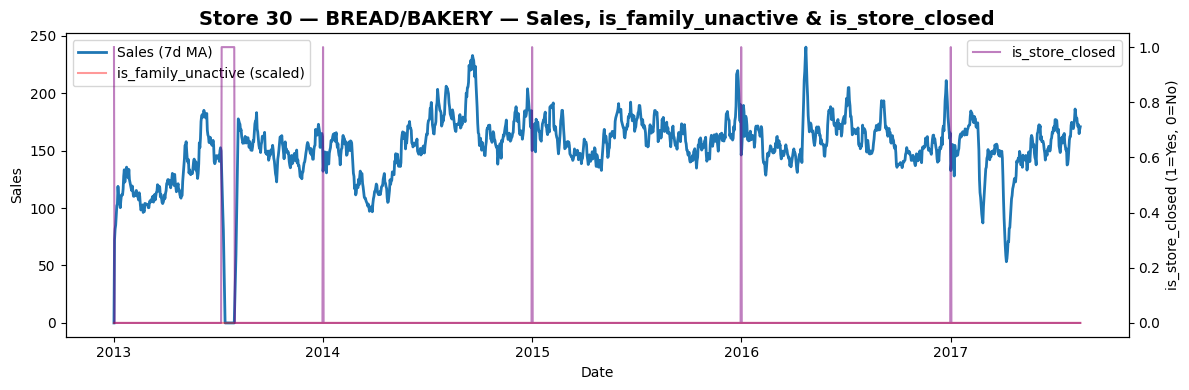

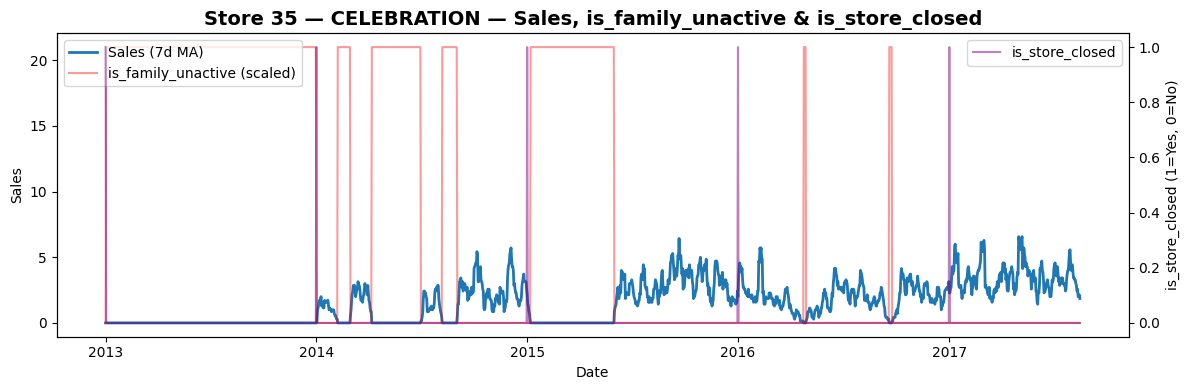

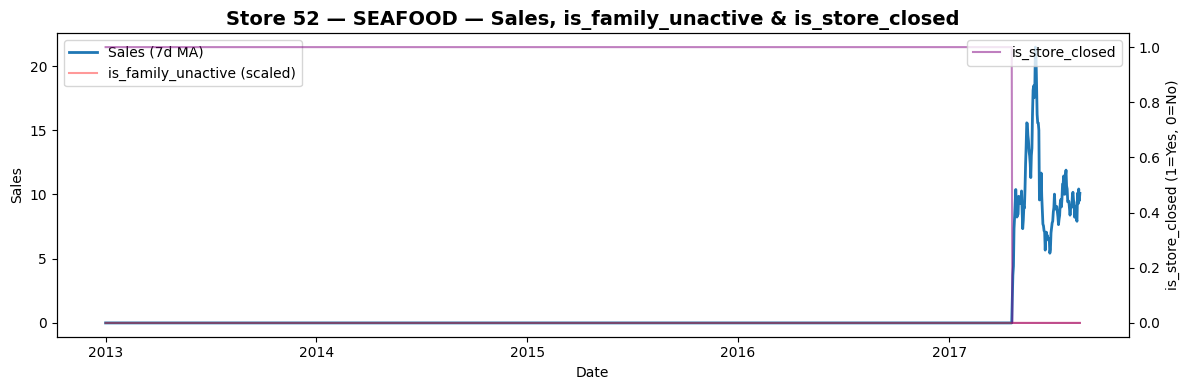

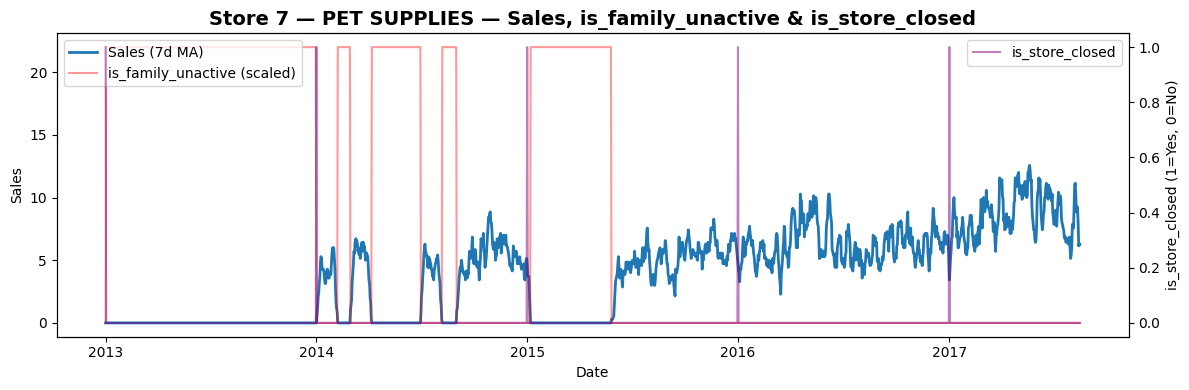

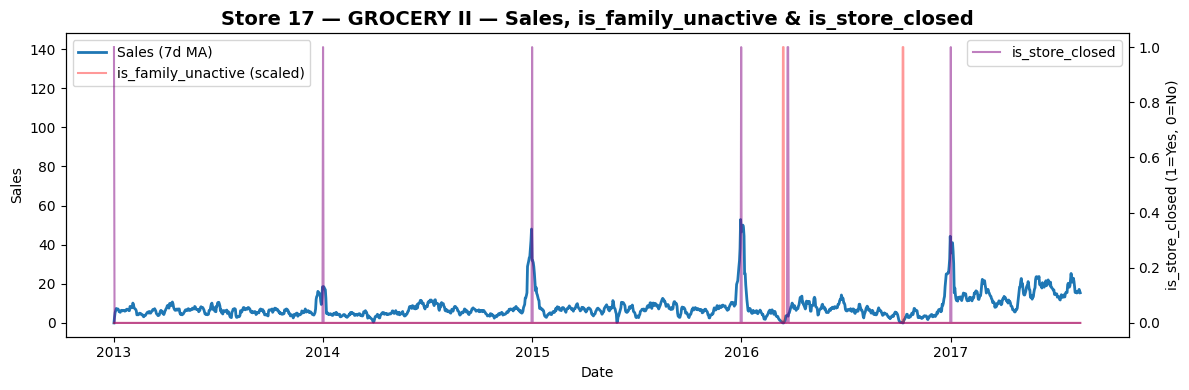

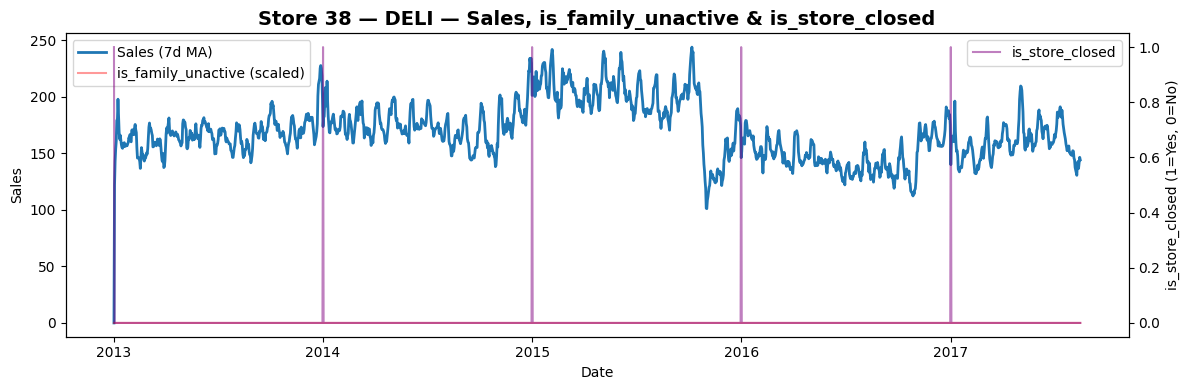

In [5]:
# Récupérer tous les couples (store_nbr, family)
couples = sales_df[['store_nbr', 'family']].drop_duplicates().values.tolist()

# Échantillonner aléatoirement 30 couples
random_couples = random.sample(couples, 30)

for store_nbr, family in random_couples:
    couple_df = sales_df[(sales_df['store_nbr'] == store_nbr) & (sales_df['family'] == family)]
    if couple_df.empty:
        continue
    daily_sales = couple_df.groupby('date')['sales'].mean()
    daily_unactive = couple_df.groupby('date')['is_family_unactive'].max()
    daily_closed = couple_df.groupby('date')['is_store_closed'].max()
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(daily_sales.index, daily_sales.rolling(7, min_periods=1).mean(), label='Sales (7d MA)', linewidth=2)
    ax1.plot(daily_unactive.index, daily_unactive.values * daily_sales.max(), color='red', alpha=0.4, label='is_family_unactive (scaled)')
    ax1.set_ylabel('Sales')
    ax1.set_xlabel('Date')
    ax2 = ax1.twinx()
    ax2.plot(daily_closed.index, daily_closed.values, color='purple', alpha=0.5, label='is_store_closed')
    ax2.set_ylabel('is_store_closed (1=Yes, 0=No)')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.title(f'Store {store_nbr} — {family} — Sales, is_family_unactive & is_store_closed', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

On observe que les données de certaines familles de produits sont absentes avant juin 2015, et parfois de manière temporaire au delà de cette date. Ceci peut être dû à différents facteurs : ruptures de stocks, ouverture d'un nouveau magasin, absence de collecte de données... Au lieu de se séparer d'une partie des données, on flague ces périodes de sorte à capturer les moments où des familles de produits ne sont pas vendues et permettre au modèle d'apprendre correctement sans se passer d'une partie des données. Les graphiques montrent bien à chaque période d'absence de vente la raison de cette absence.  
  
Rappels :  
- Un magasin est considéré fermé si il ne vend aucun produit pour un jour donné. 
- Une famille est considérée inactive si on n'observe aucune vente pendant 7 jours d'affilé ET que le magasin est bien ouvert néanmoins. 

Une fois en production, c'est également utile pour mieux prédire les ventes du magasin sur une période de temps future puisque généralement on connait les dates de fermeture du magasin (ex: travaux) ou les périodes où l'on ne possédera pas certains produits (du moins parfois ce sont des choses que l'on sait, les ruptures de stock ne sont pas toujours prévisbiles mais dans tous les cas le modèle se tromperait).

# 2. Familles de produits avec peu de ventes 

In [6]:
def get_low_volume_families(df, threshold=None):

    if threshold is None:
        # Seuil moyen de 10 ventes par magasin par jour pour chaque famille
        threshold = 10 * df.groupby('family', observed=False)['sales'].mean().mean() / df['store_nbr'].nunique()
        print(f"Seuil par défaut défini à {threshold:.4f} ventes/jour")
                       
    # Calculer le total des ventes par jour et par famille
    # On groupe par date et famille pour avoir la somme globale (tous magasins confondus)
    daily_family_sales = df.groupby(['date', 'family'], observed=False)['sales'].sum().reset_index()
    
    # Calculer la moyenne quotidienne pour chaque famille
    mean_daily_sales = daily_family_sales.groupby('family', observed=False)['sales'].mean().sort_values()
    
    # Filtrer les familles sous le seuil
    low_volume_families = mean_daily_sales[mean_daily_sales < threshold]
    
    print(f"--- Familles avec moins de {threshold} vente(s) par jour en moyenne ---")
    if low_volume_families.empty:
        print("Aucune famille trouvée sous ce seuil.")
    else:
        for family, value in low_volume_families.items():
            print(f"- {family:.<30} {value:.4f} ventes/jour")
            
    return low_volume_families.index.tolist()

low_families = get_low_volume_families(sales_df, threshold=None)

Seuil par défaut défini à 66.2548 ventes/jour
--- Familles avec moins de 66.25476837158203 vente(s) par jour en moyenne ---
- BOOKS......................... 3.8230 ventes/jour
- BABY CARE..................... 5.9685 ventes/jour
- HOME APPLIANCES............... 24.7037 ventes/jour
- HARDWARE...................... 61.4430 ventes/jour


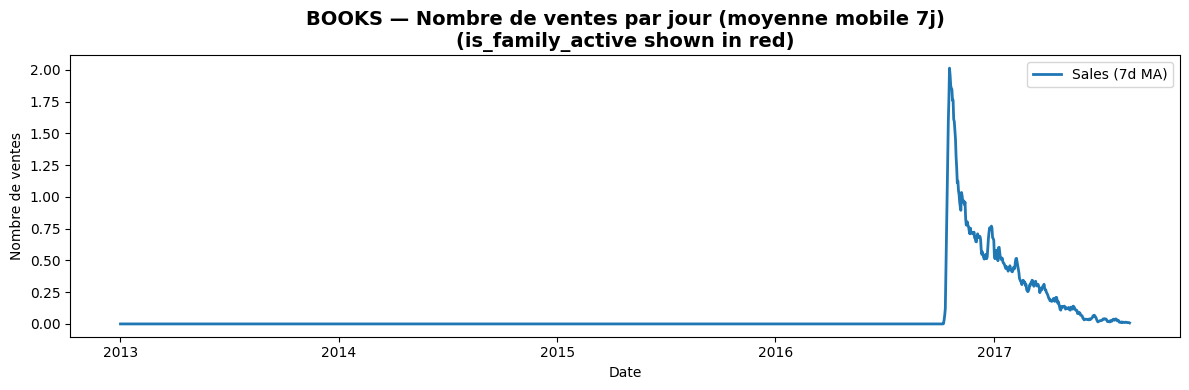

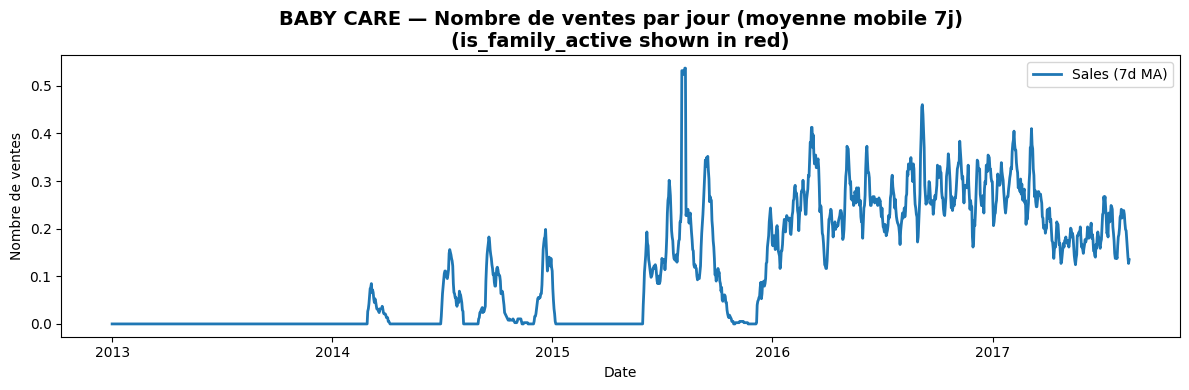

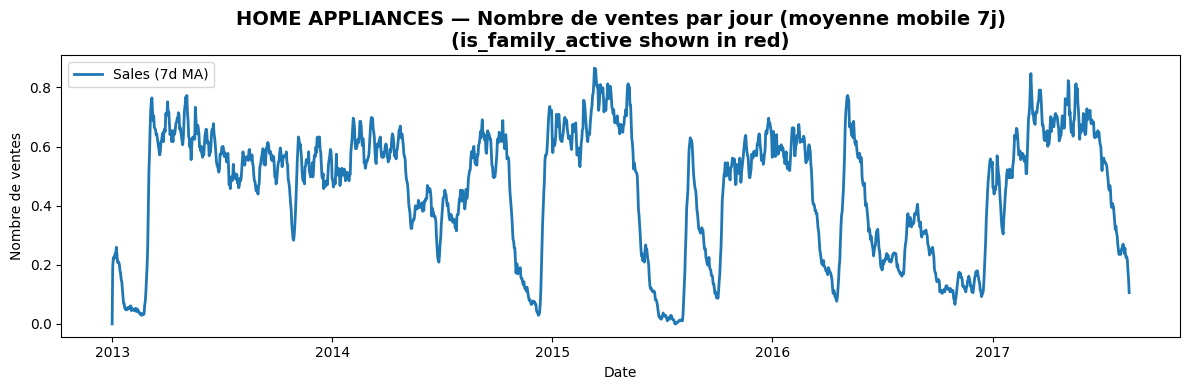

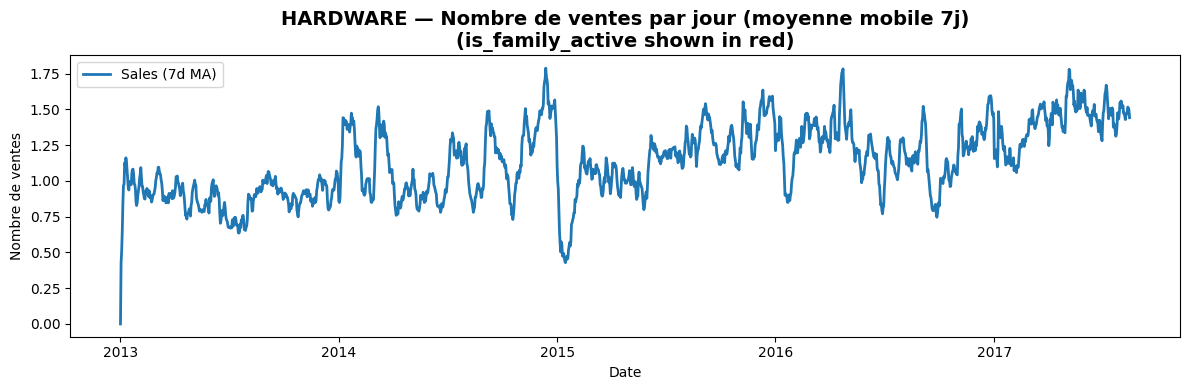

In [7]:
for fam in ["BOOKS", "BABY CARE", "HOME APPLIANCES", "HARDWARE" ]:
    fam_df = sales_df[sales_df['family'] == fam]
    fam_daily_counts = fam_df.groupby('date')["sales"].mean()
    plt.figure(figsize=(12, 4))
    plt.plot(fam_daily_counts.index, fam_daily_counts.rolling(7, min_periods=1).mean(), label='Sales (7d MA)', linewidth=2)
    plt.title(f'{fam} — Nombre de ventes par jour (moyenne mobile 7j)\n(is_family_active shown in red)', fontsize=14, fontweight='bold')
    plt.ylabel('Nombre de ventes')
    plt.xlabel('Date')
    plt.legend()
    plt.tight_layout()
    plt.show()

Sur ces variables le feature engineering sera très important. Pour des modèles de ML on peut être amené à supprimer books ou regrouper avec une autre famille même si les graphiques ci dessus montrent que cela ne fait pas forcément trop sens. Pour des modèles de DL l'embedding peut gérer. Pour ces familles, un target encoding (ou catboost encoding) avec un alpha fort pour lisser le signal sera nécessaire. 

# 3. Stores 

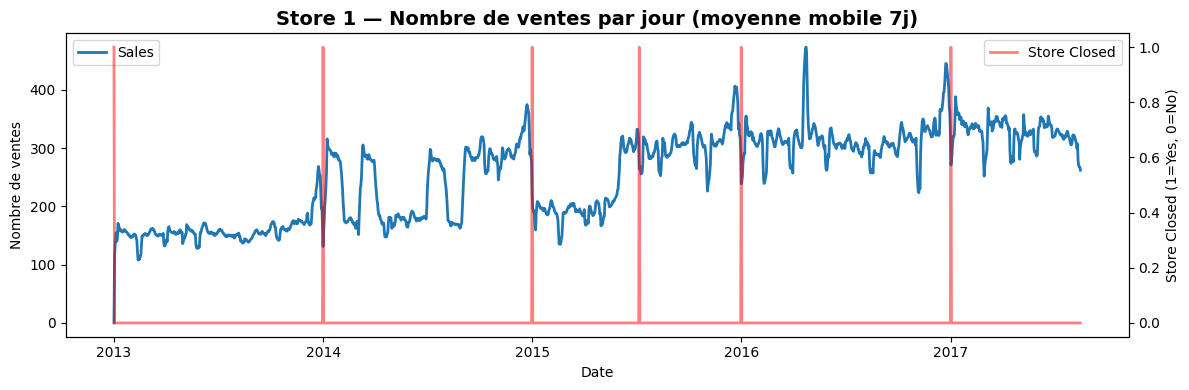

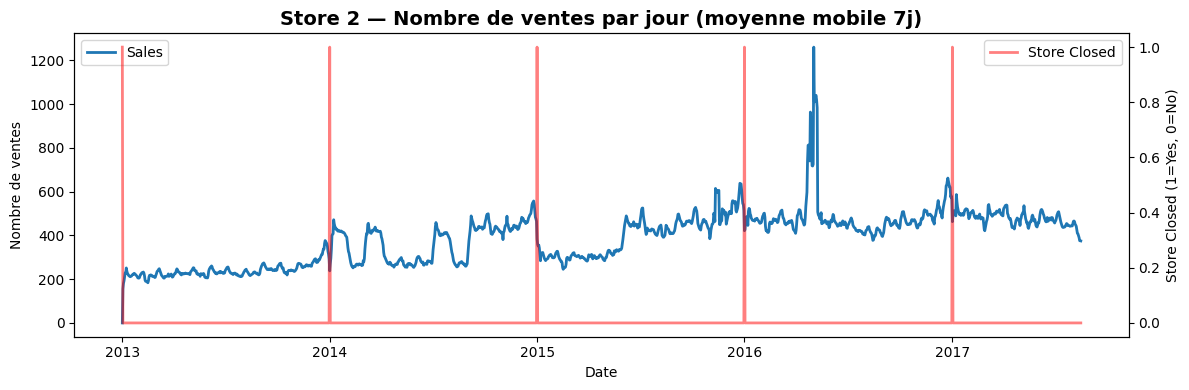

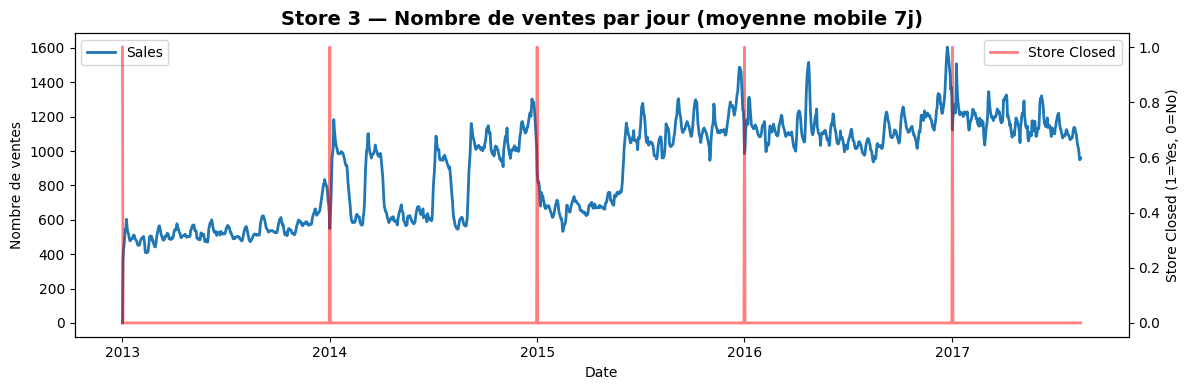

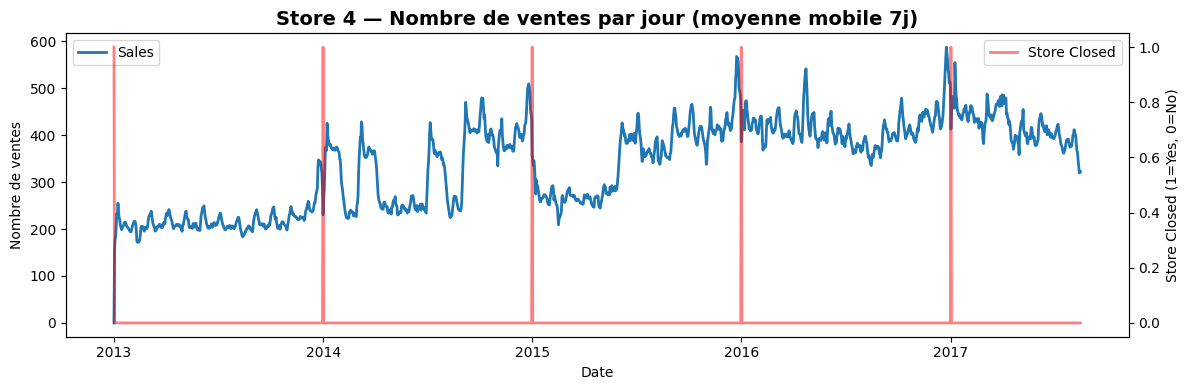

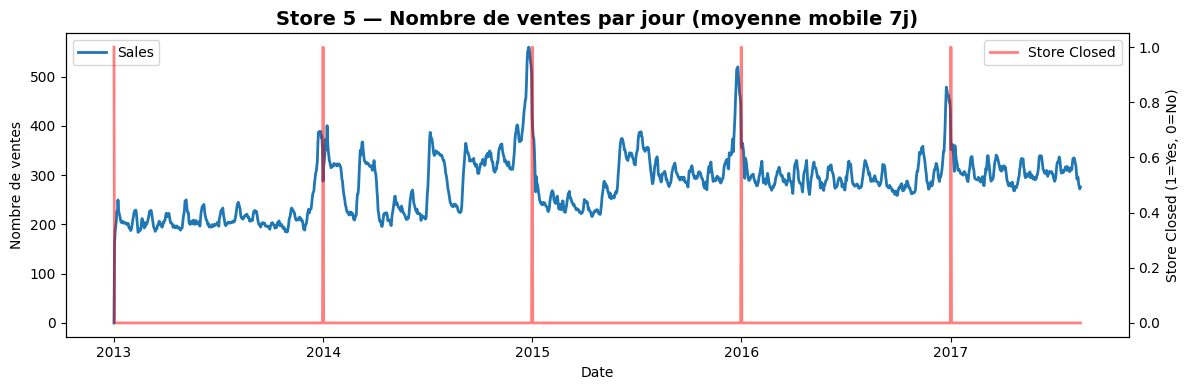

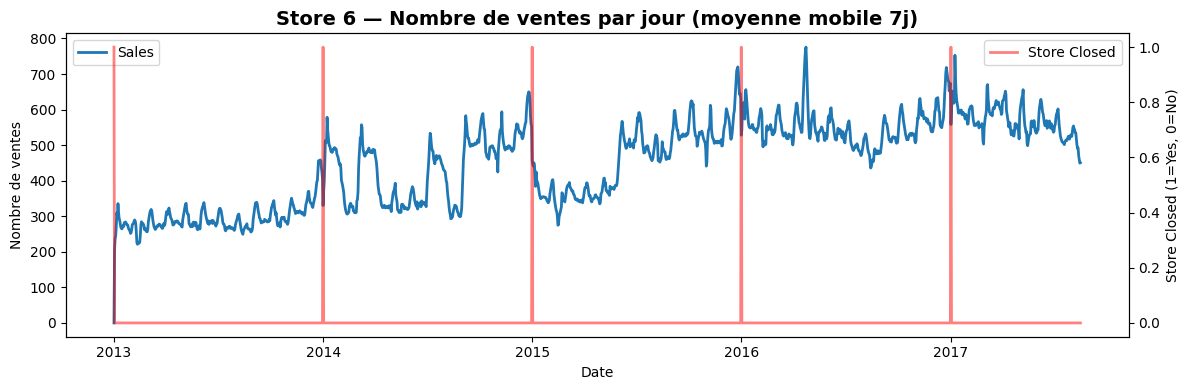

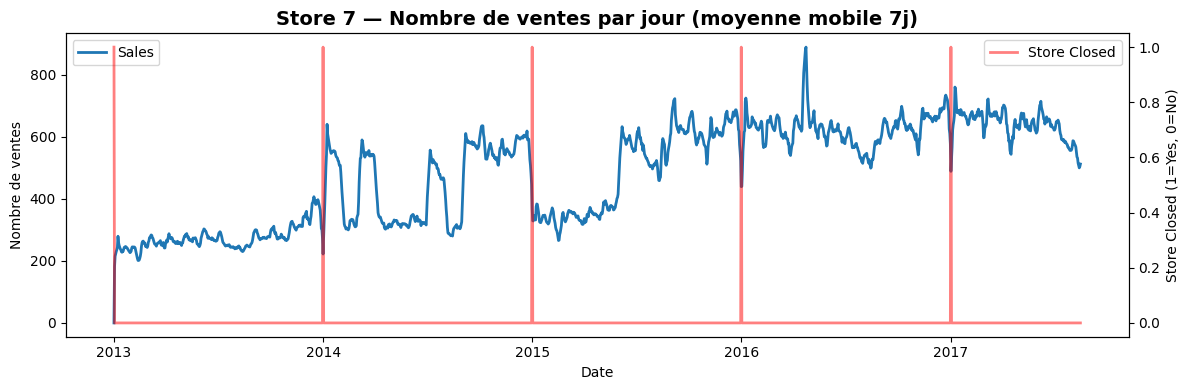

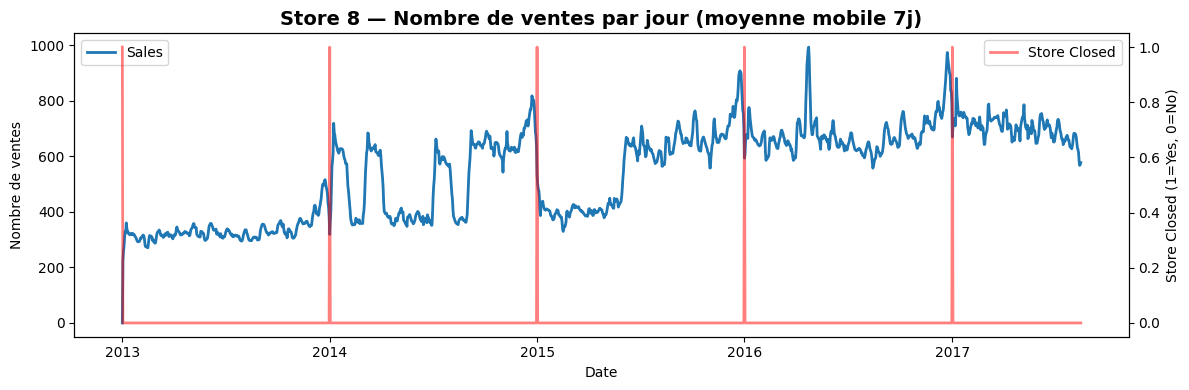

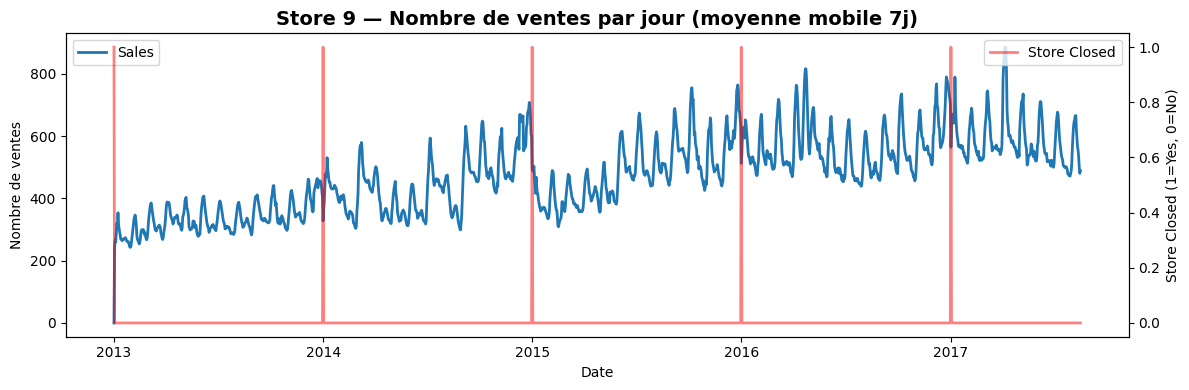

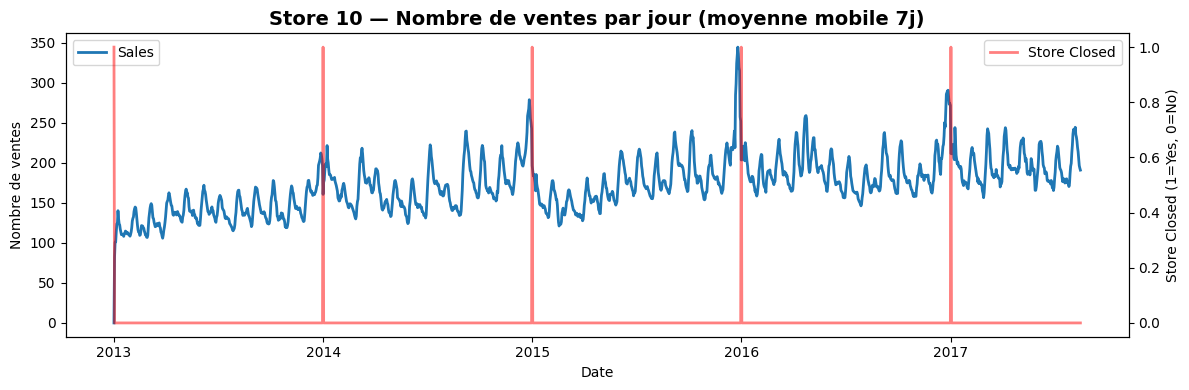

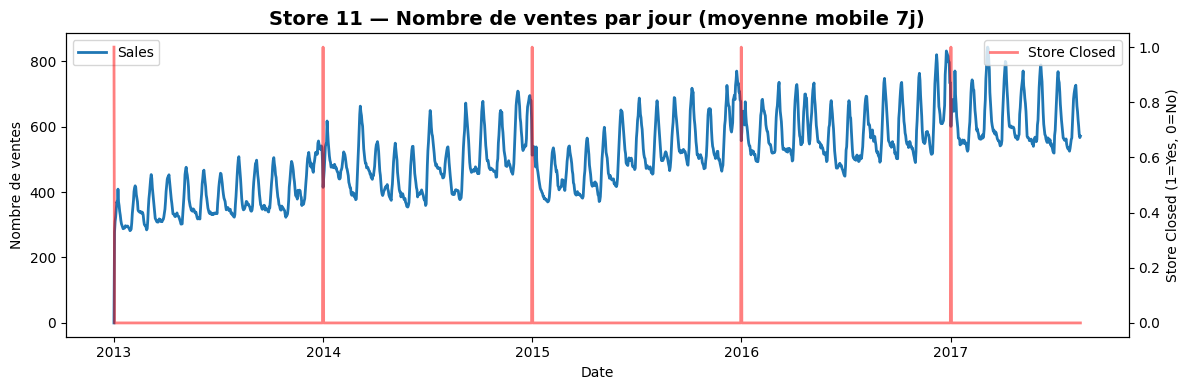

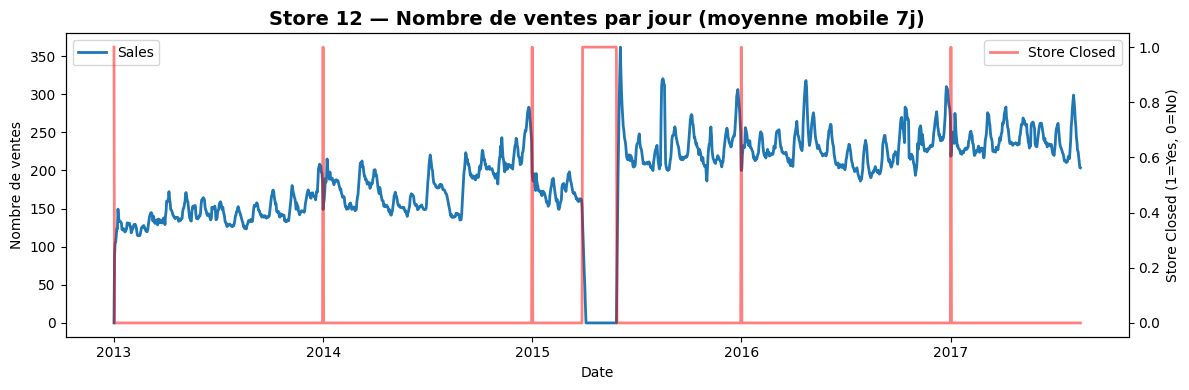

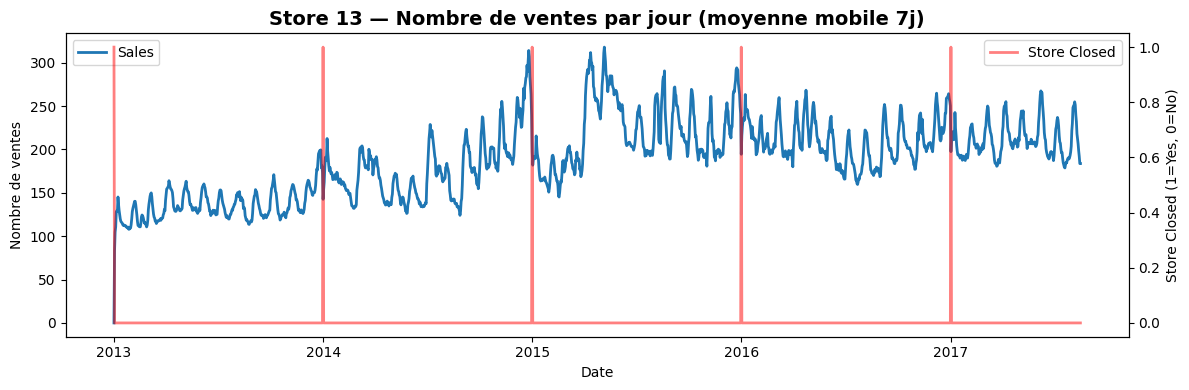

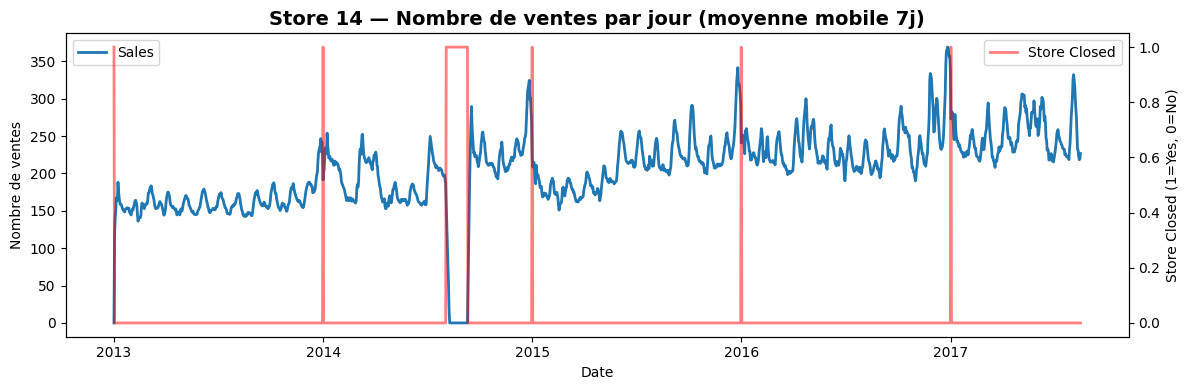

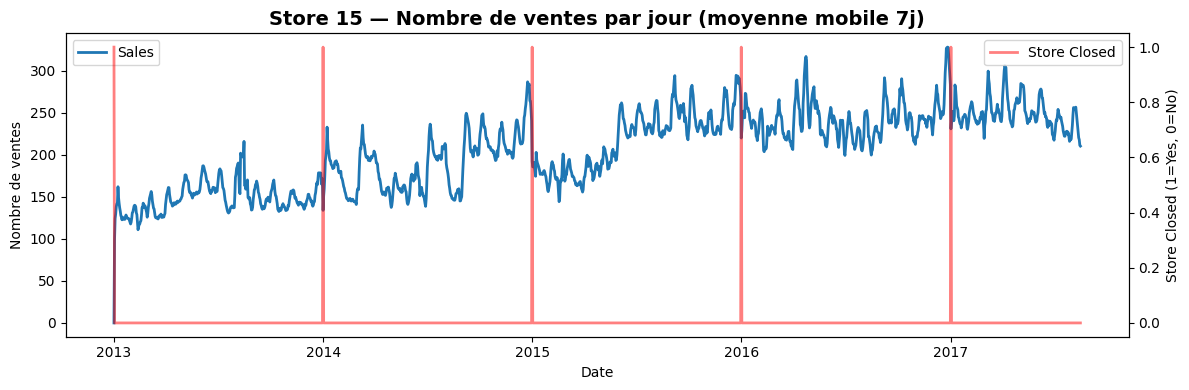

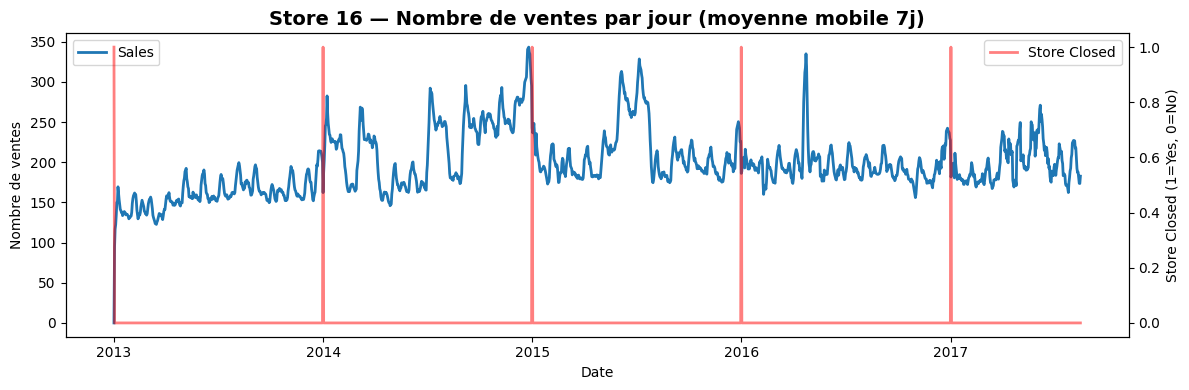

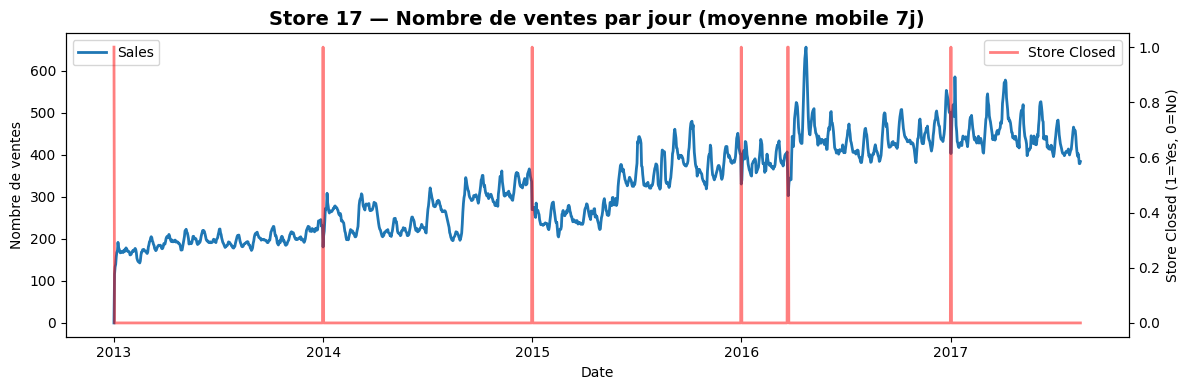

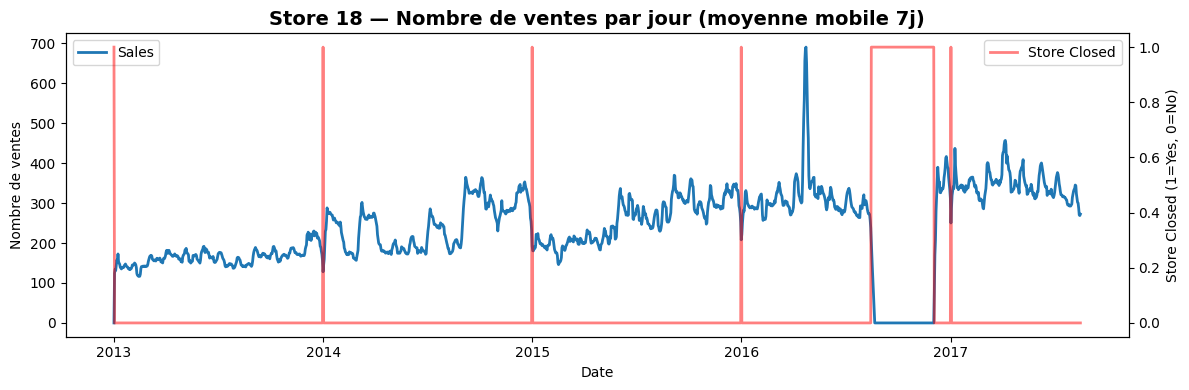

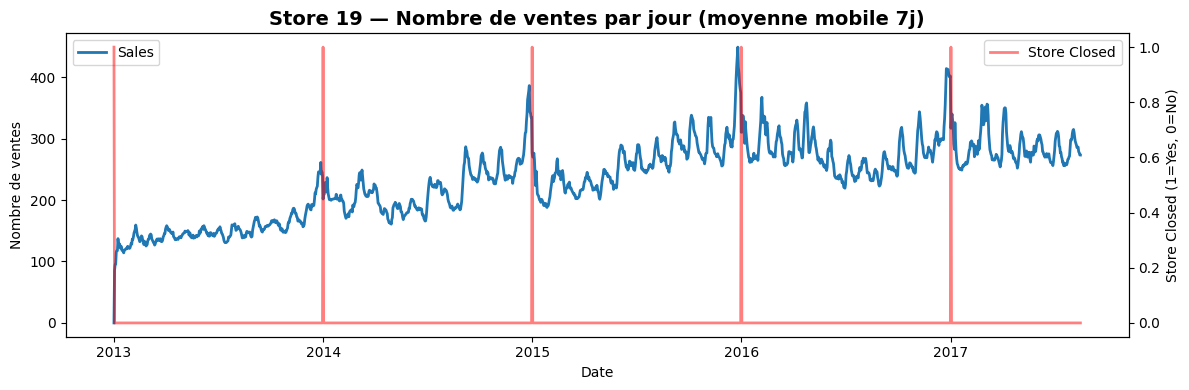

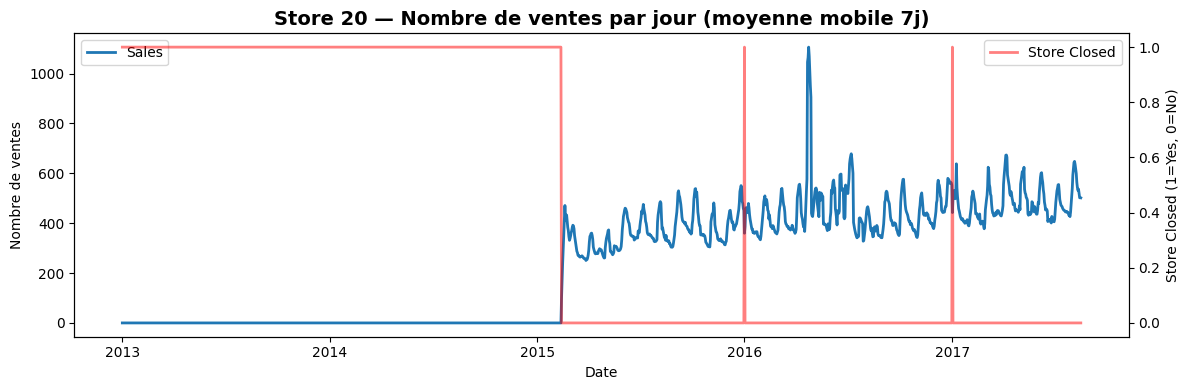

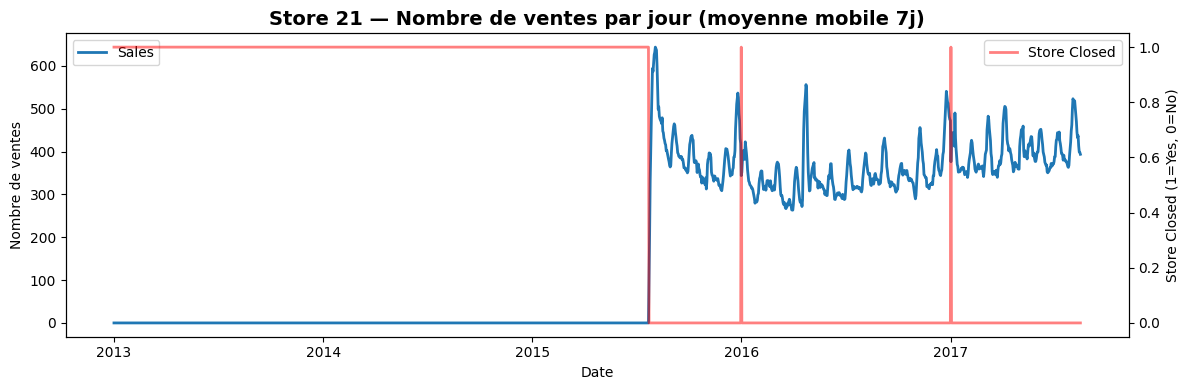

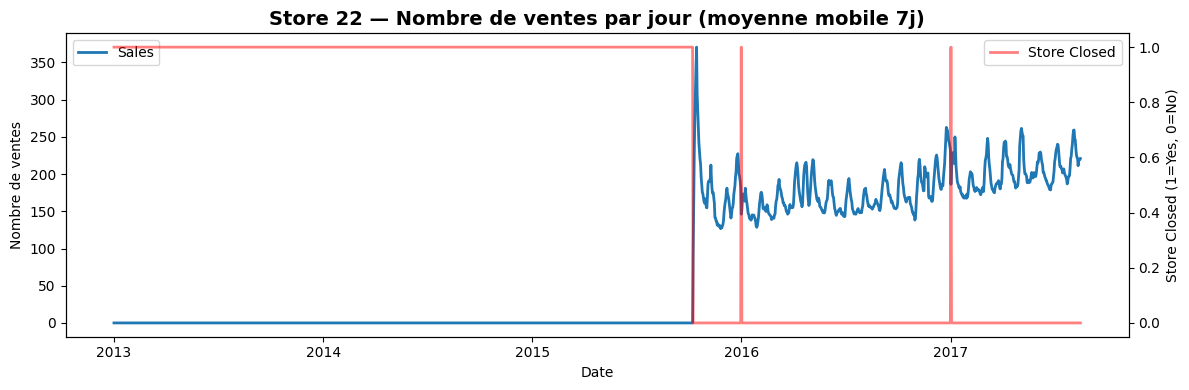

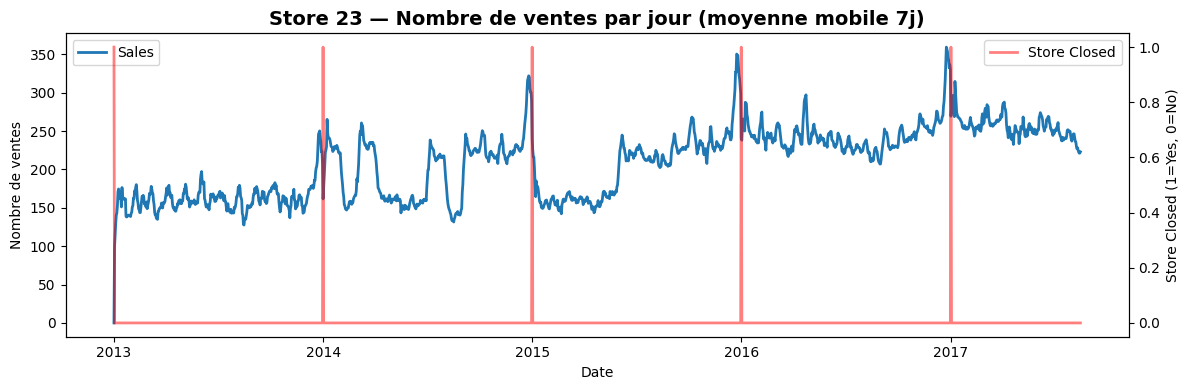

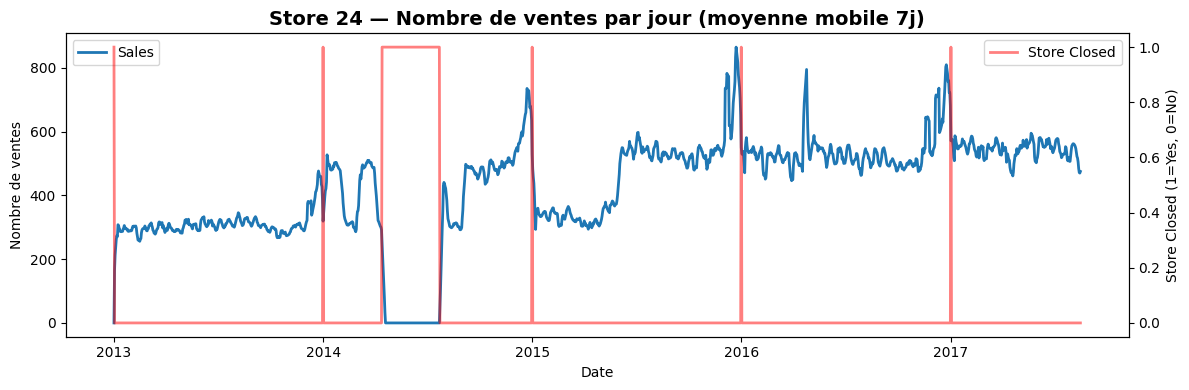

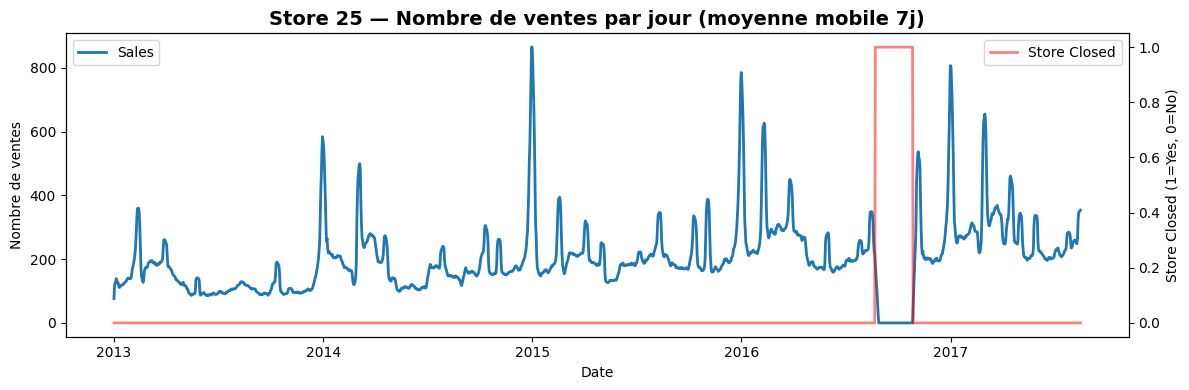

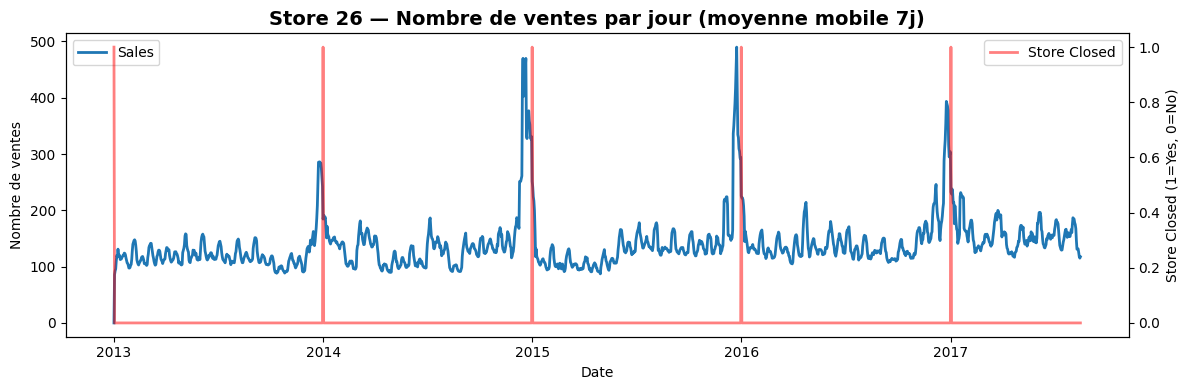

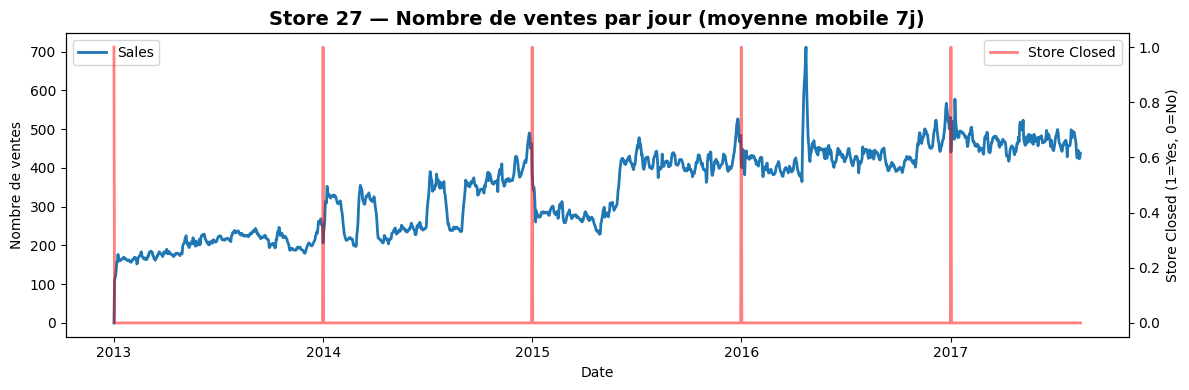

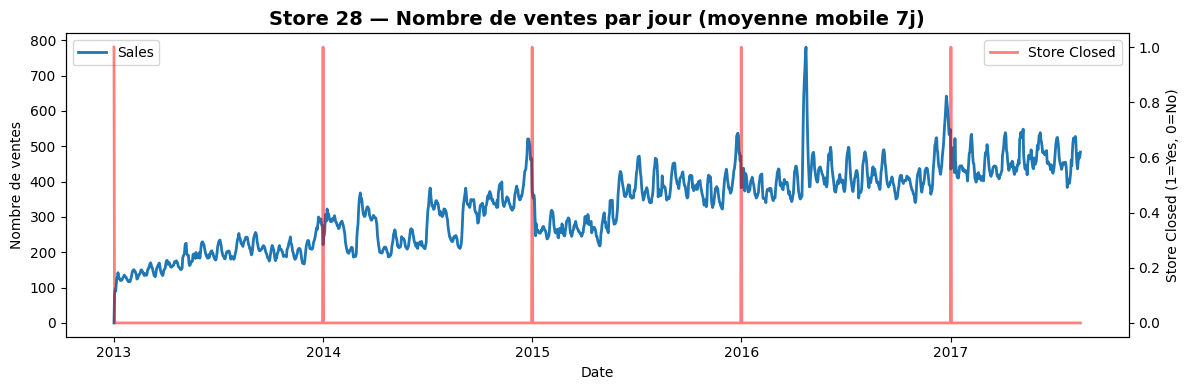

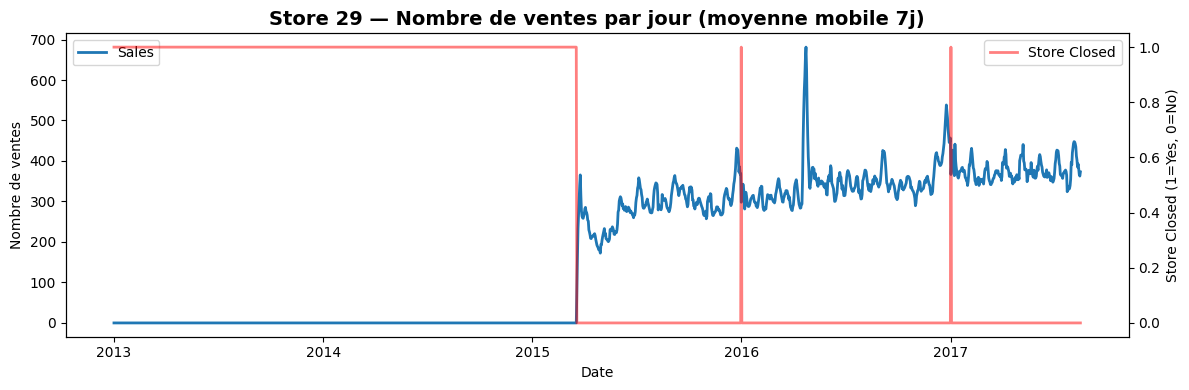

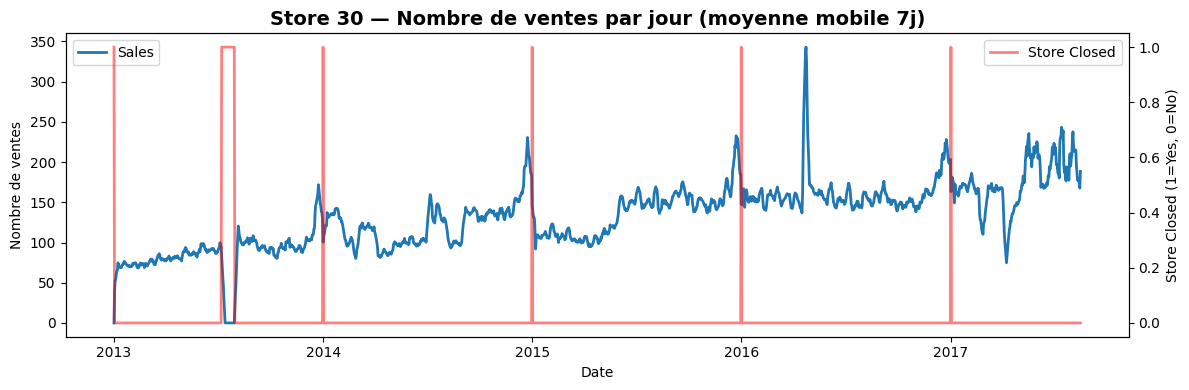

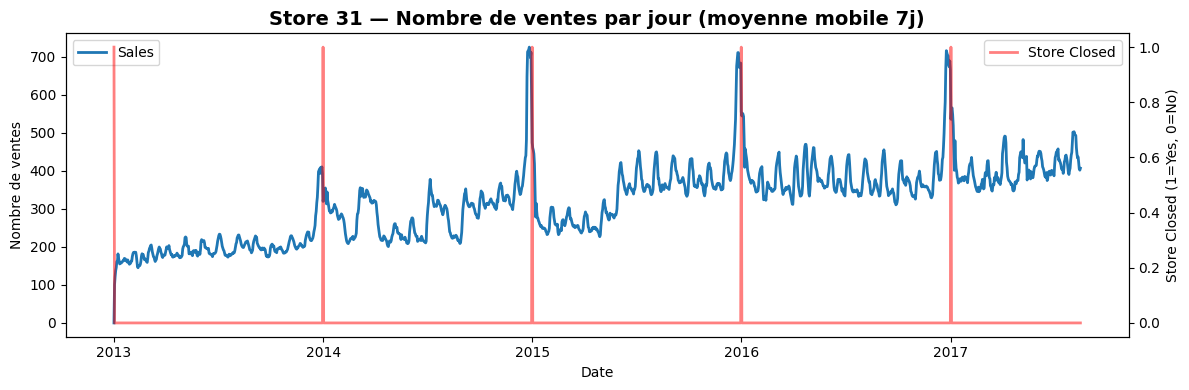

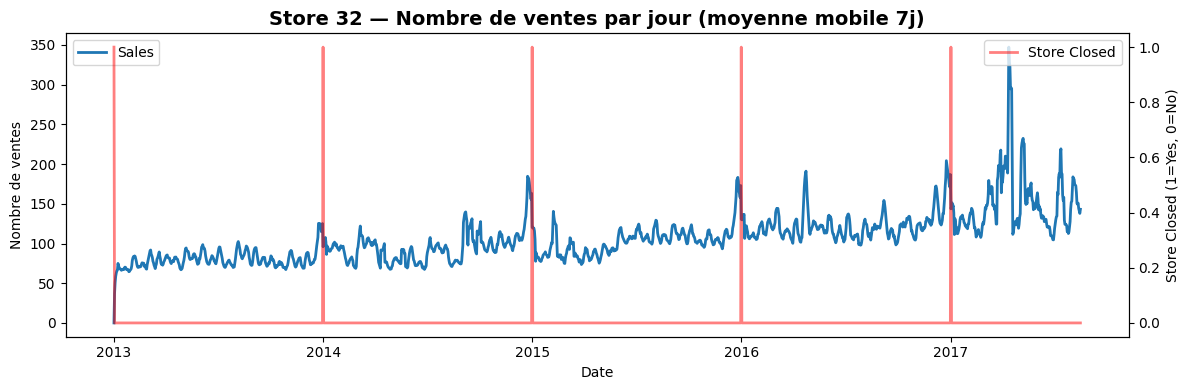

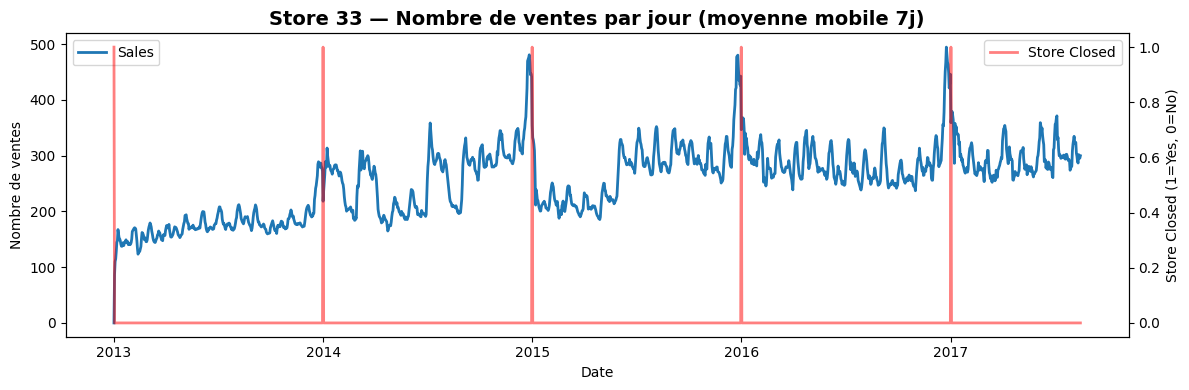

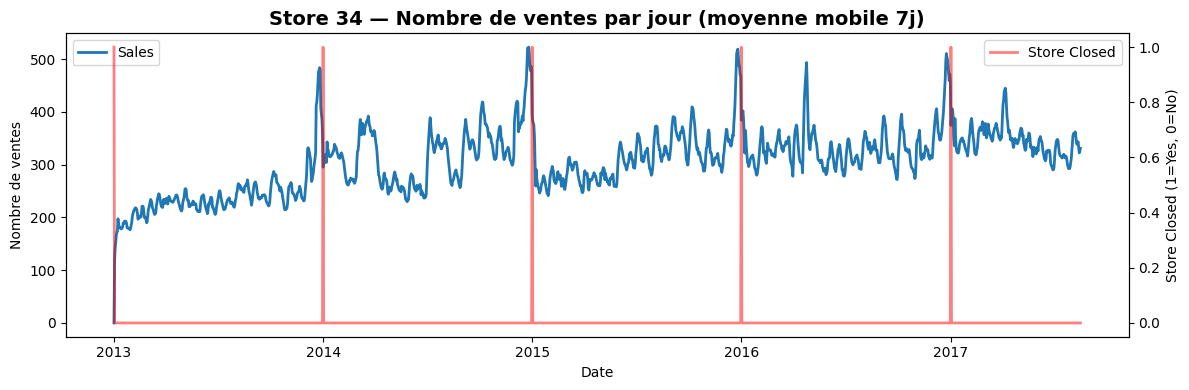

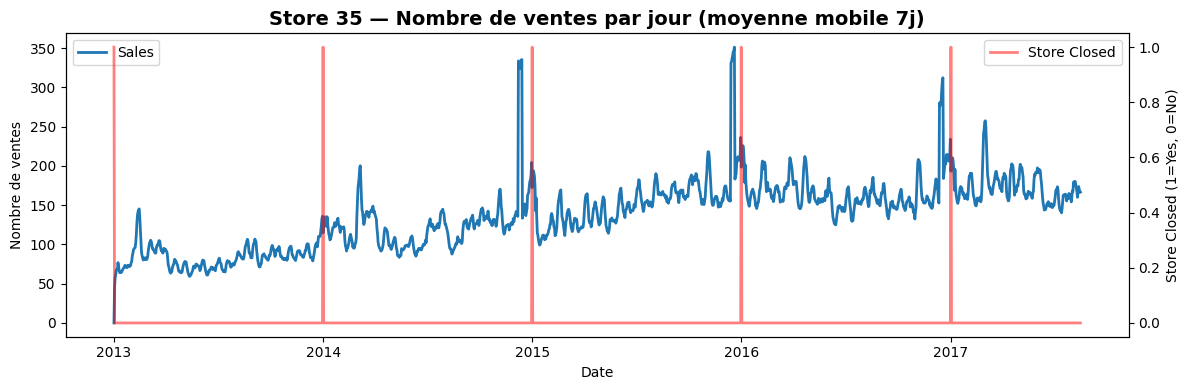

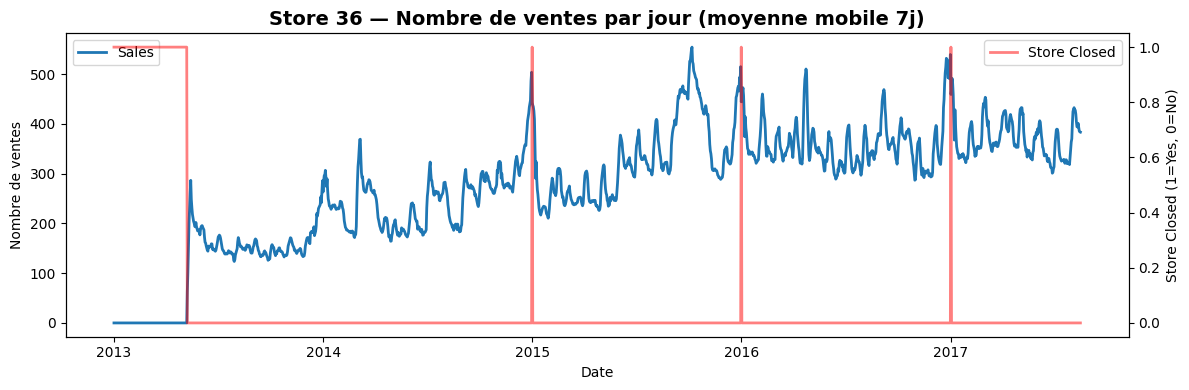

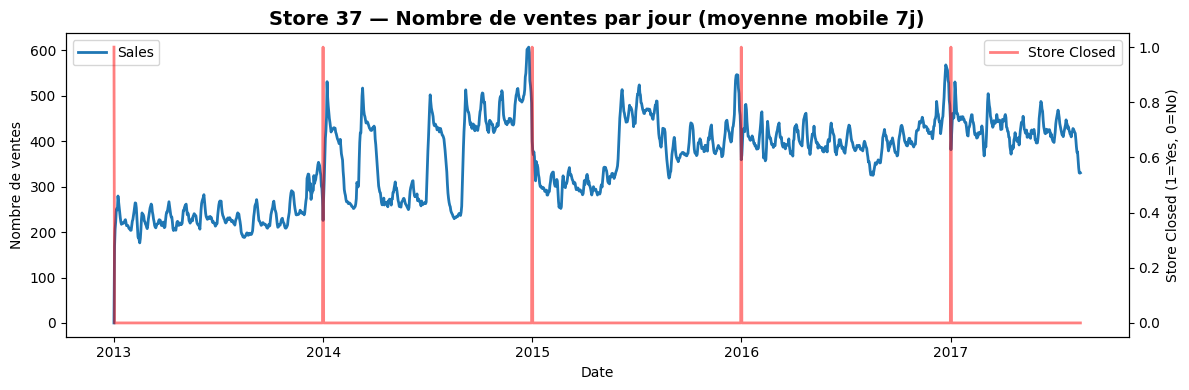

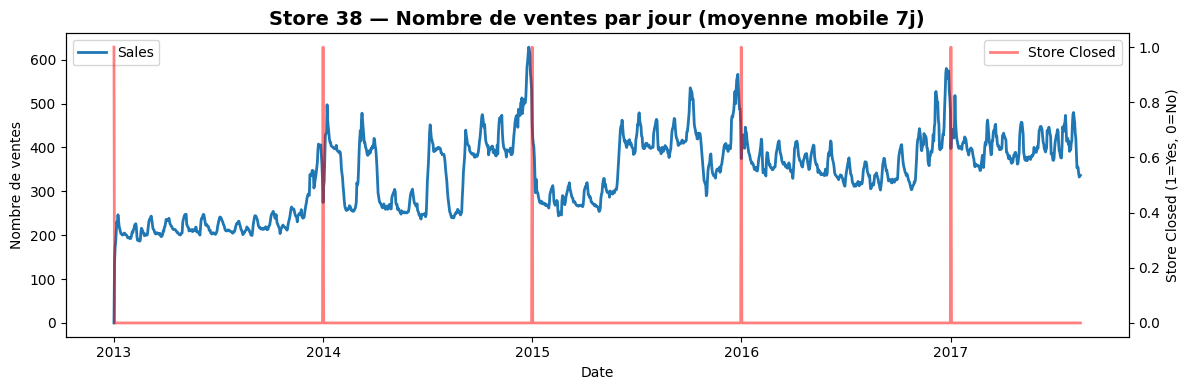

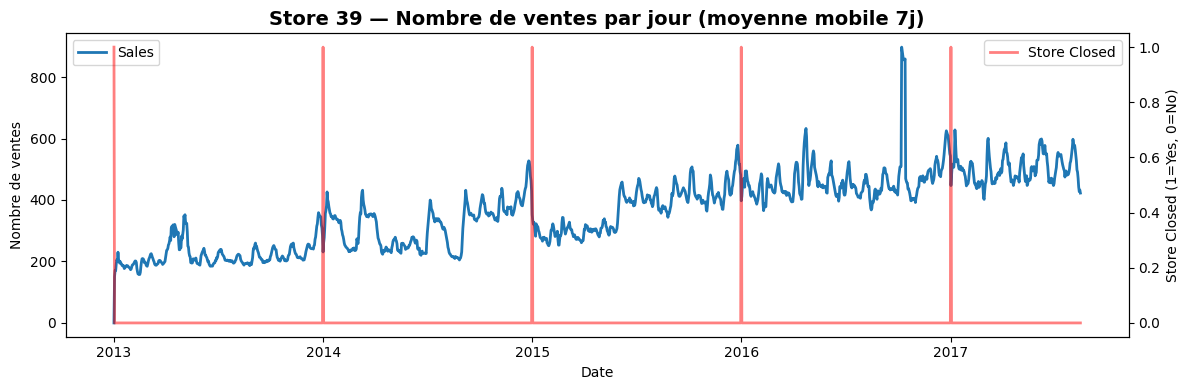

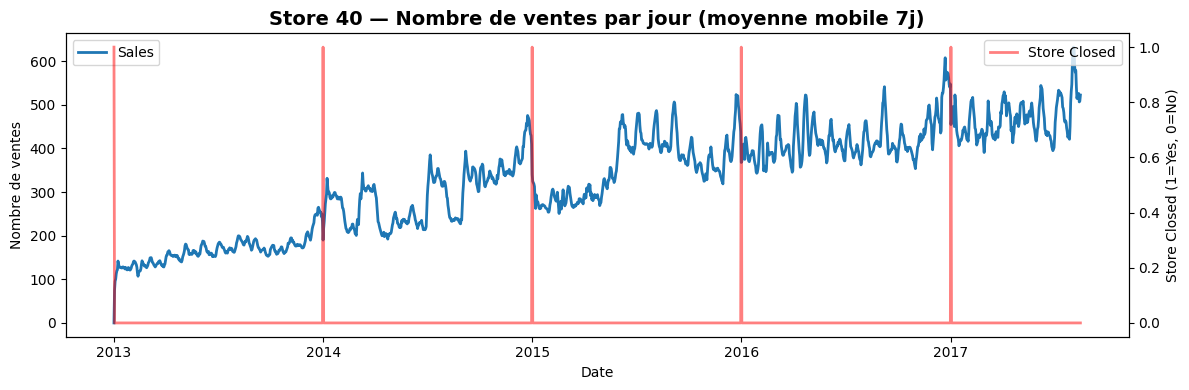

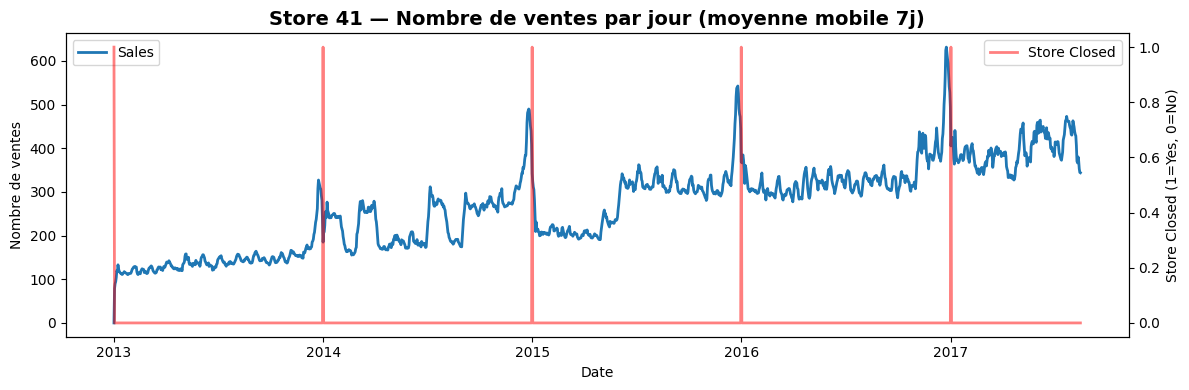

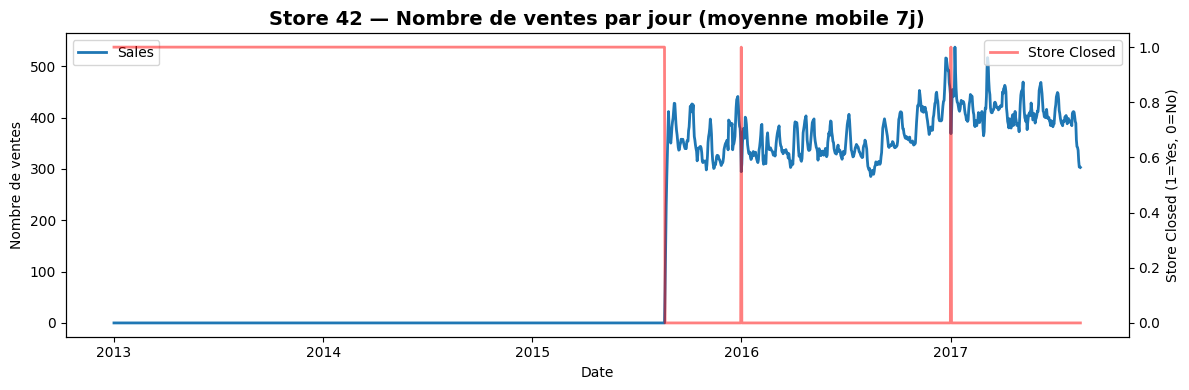

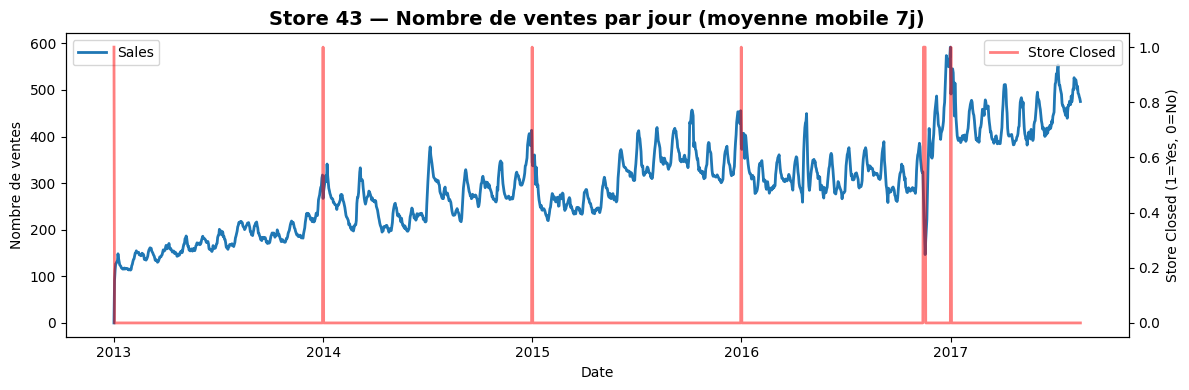

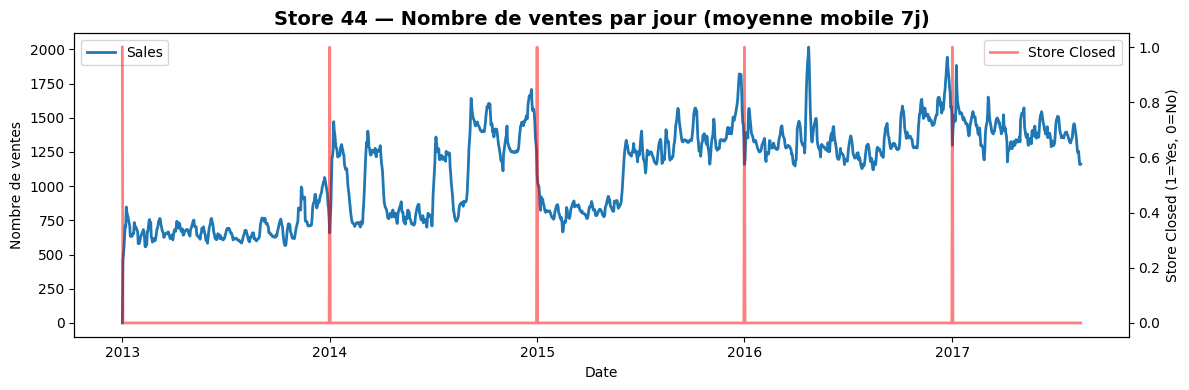

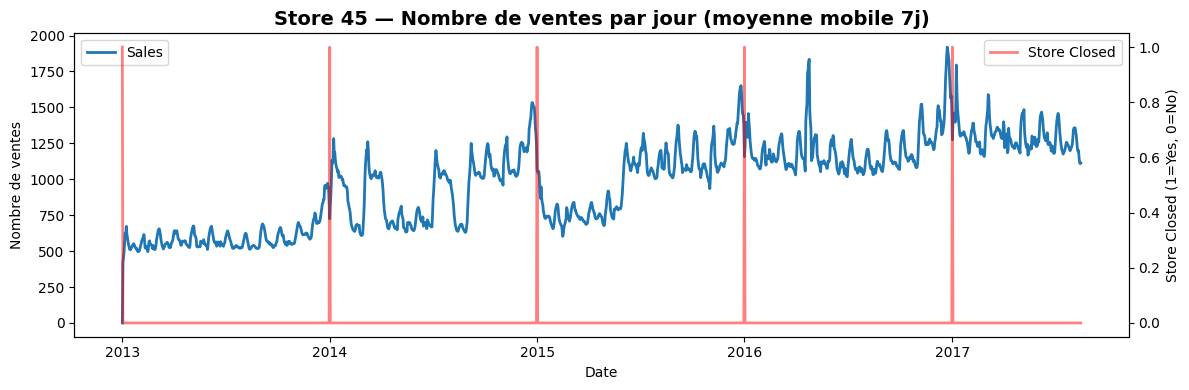

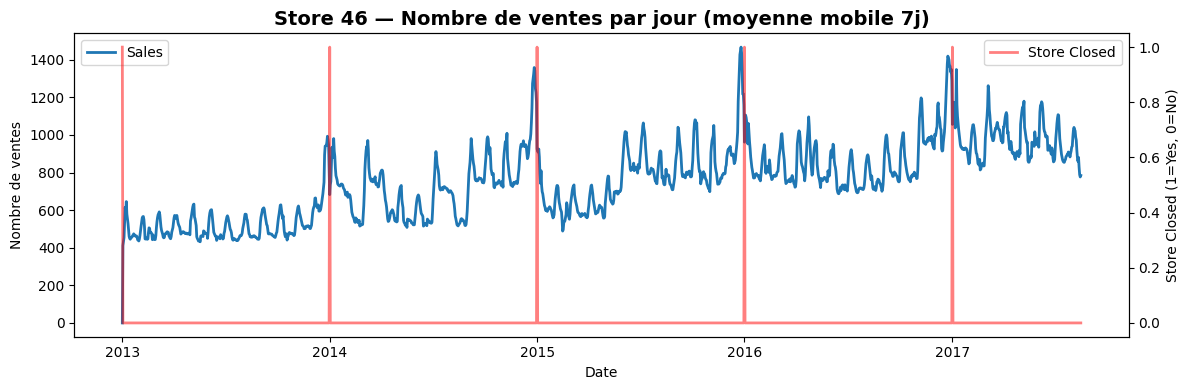

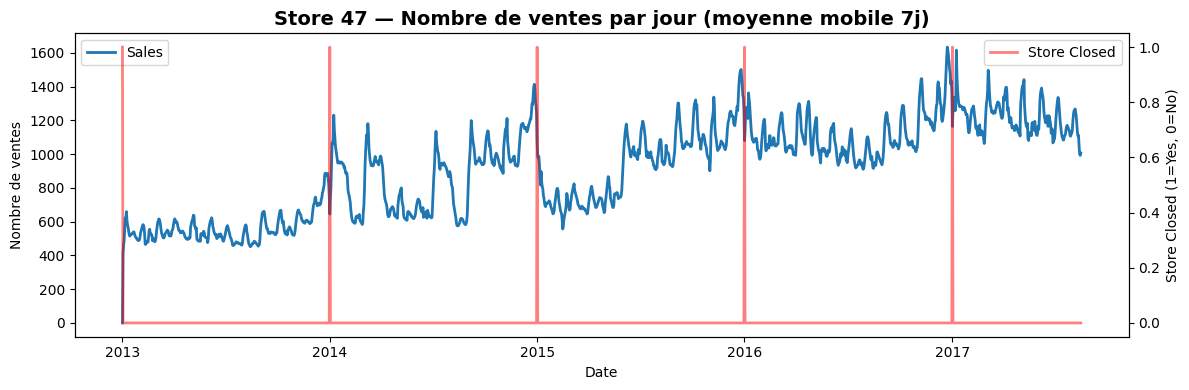

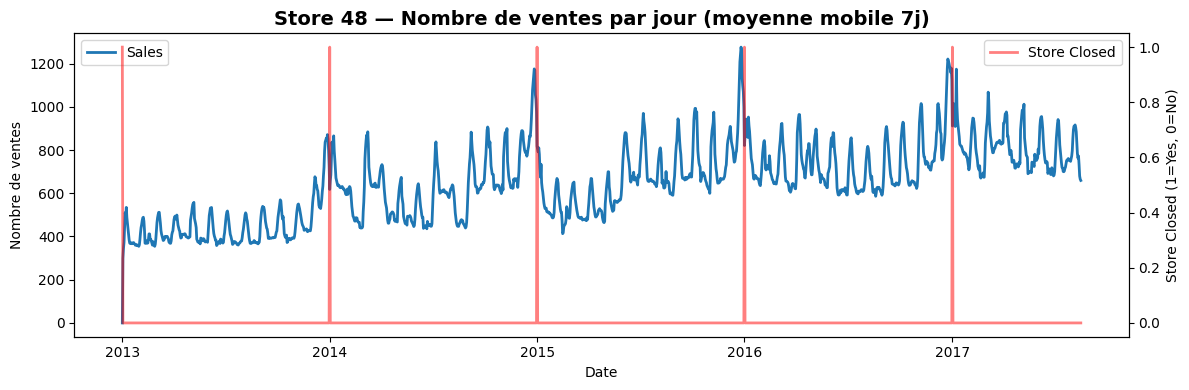

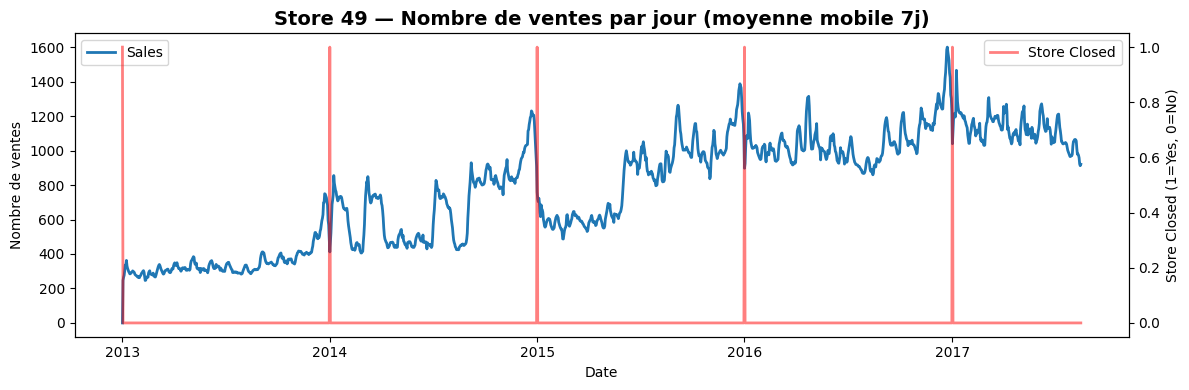

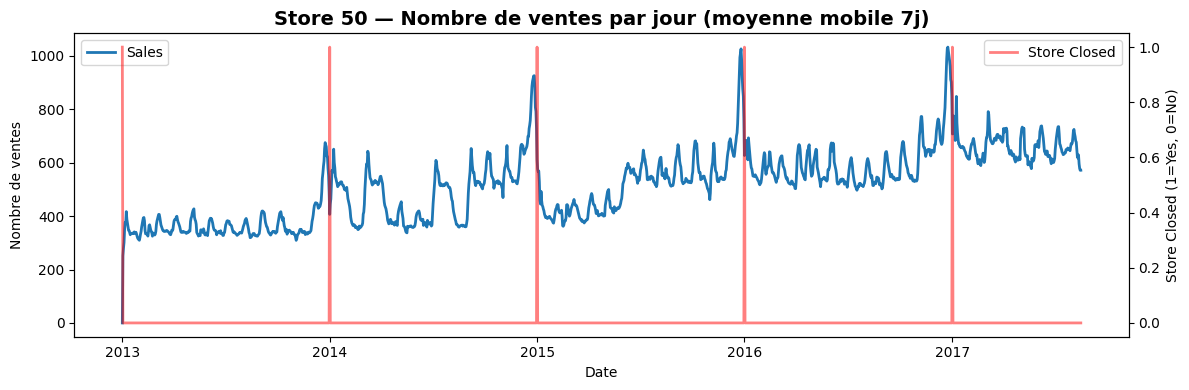

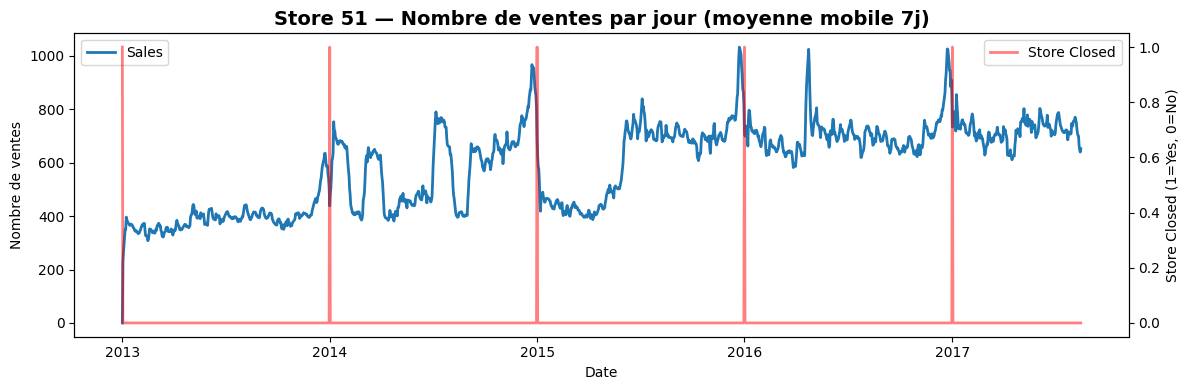

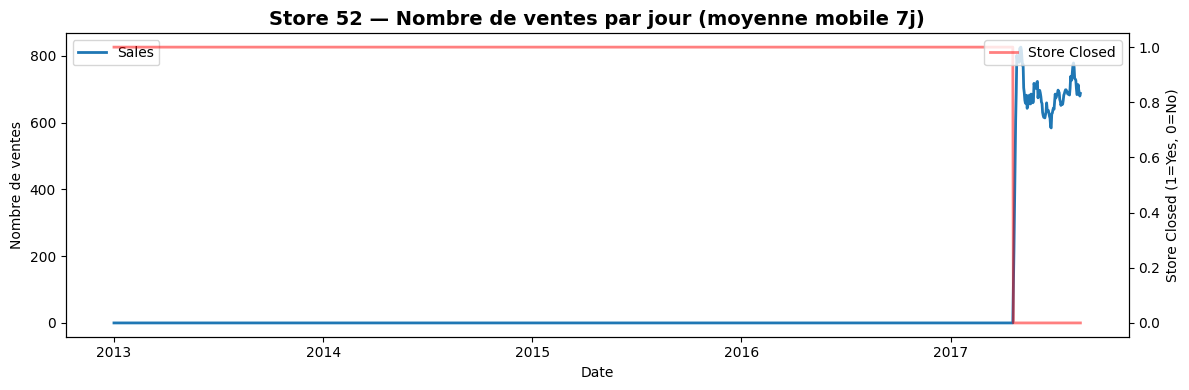

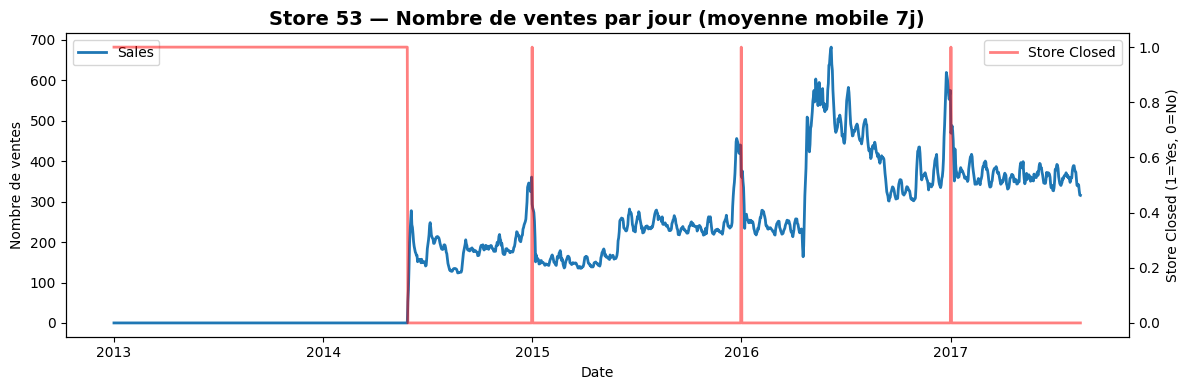

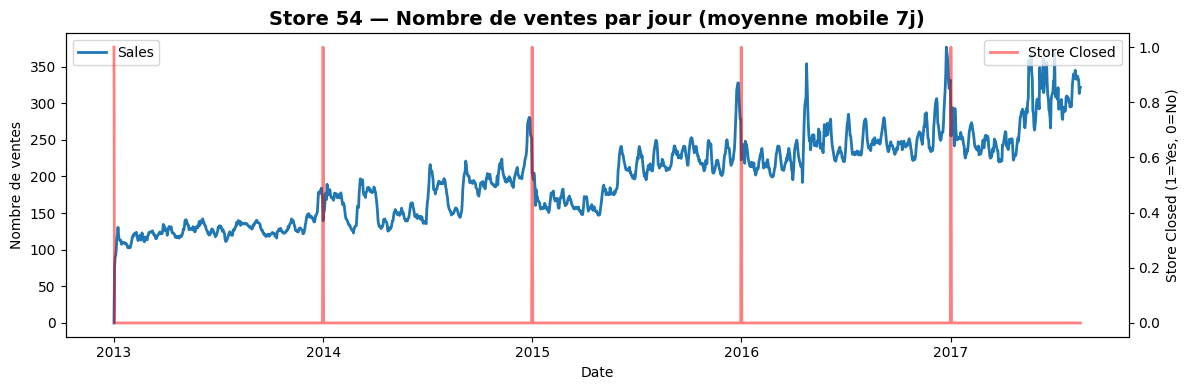

In [8]:
stores = sales_df['store_nbr'].value_counts().index.tolist()

for store in stores:
    store_daily_counts = sales_df[sales_df['store_nbr'] == store].groupby('date')["sales"].mean()
    store_closed = sales_df[sales_df['store_nbr'] == store].groupby('date')["is_store_closed"].max()
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(store_daily_counts.index, store_daily_counts.rolling(7, min_periods=1).mean(), label='Sales', linewidth=2)
    ax1.set_ylabel('Nombre de ventes')
    ax1.set_xlabel('Date')
    ax1.set_title(f'Store {store} — Nombre de ventes par jour (moyenne mobile 7j)', fontsize=14, fontweight='bold')
    ax2 = ax1.twinx()
    ax2.plot(store_closed.index, store_closed.values, color='red', label='Store Closed', alpha=0.5, linewidth=2)
    ax2.set_ylabel('Store Closed (1=Yes, 0=No)')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

Notre variable is_store_closed nous permet de bien capter toutes les fermetures de magasin. 